In [ ]:
!pip install librosa soundfile ruptures

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import librosa
import soundfile as sf
import numpy as np
import ruptures as rpt
import os

# Load audio
audio_file = "/content/drive/MyDrive/colab_datas/isp_comm/bird_sound_shorts_1.m4a"

y, sr = librosa.load(audio_file, sr=16000)

# MFCC features
mfcc = librosa.feature.mfcc(
    y=y,
    sr=sr,
    n_mfcc=20,
    hop_length=160,
    n_fft=400
).T

# Change point detection
algo = rpt.Pelt(model="rbf").fit(mfcc)
breaks = algo.predict(pen=8)

hop = 160

os.makedirs("segments", exist_ok=True)

start = 0

for i, end_frame in enumerate(breaks):
    end = end_frame * hop

    if end - start < sr * 0.15:
        continue

    segment = y[start:end]

    sf.write(
        f"segments/segment_{i:04d}.wav",
        segment,
        sr
    )

    start = end

print("Done")

/tmp/ipykernel_1365/3650775173.py:10: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(audio_file, sr=16000)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


Done


In [ ]:
import librosa
import numpy as np
import ruptures as rpt
from IPython.display import Audio, display, Markdown

#audio_file = "/content/input.wav"
audio_file = "/content/drive/MyDrive/colab_datas/isp_comm/bird_sound_shorts_1.m4a"

# Load audio
y, sr = librosa.load(audio_file, sr=16000)

# Extract MFCC features
mfcc = librosa.feature.mfcc(
    y=y,
    sr=sr,
    n_mfcc=20,
    hop_length=160,
    n_fft=400
).T

# Detect change points
algo = rpt.Pelt(model="rbf").fit(mfcc)
breaks = algo.predict(pen=8)

hop = 160
start = 0

print(f"Detected {len(breaks)} candidate segments\n")

for i, end_frame in enumerate(breaks):
    end = end_frame * hop

    # Skip segments shorter than 150 ms
    if end - start < int(sr * 0.15):
        continue

    segment = y[start:end]

    duration = len(segment) / sr

    display(Markdown(
        f"### Segment {i+1}\n"
        f"- Start: **{start/sr:.2f} s**\n"
        f"- End: **{end/sr:.2f} s**\n"
        f"- Duration: **{duration:.2f} s**"
    ))

    display(Audio(segment, rate=sr))

    start = end

DISPLAY

/tmp/ipykernel_1365/497986913.py:9: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(audio_file, sr=None, mono=True)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


Sample Rate: 44100
Duration: 1.00 seconds
Samples: 44000


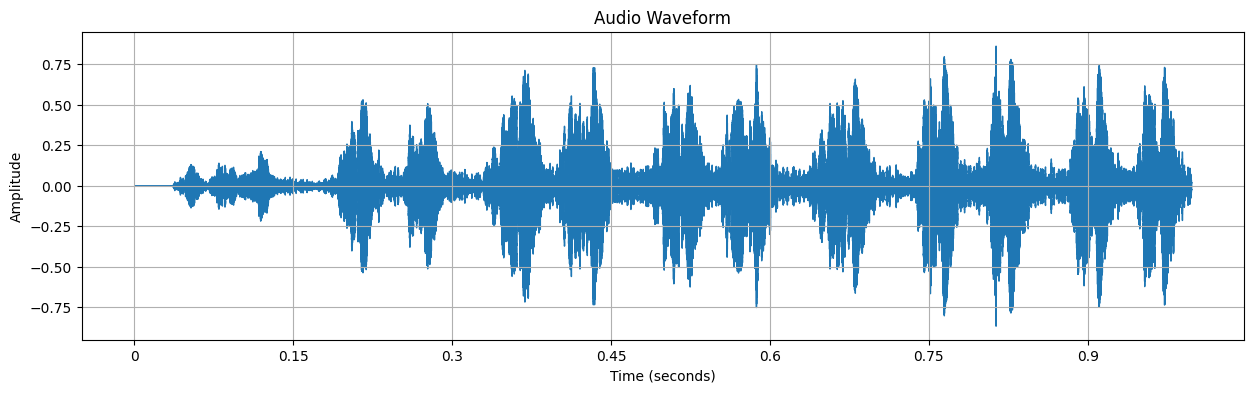

In [4]:
import librosa
import librosa.display
import matplotlib.pyplot as plt

# Path to your audio
#audio_file = "/content/input.wav"

# Load audio
y, sr = librosa.load(audio_file, sr=None, mono=True)

def show_audio(y, sr):
  print(f"Sample Rate: {sr}")
  print(f"Duration: {len(y)/sr:.2f} seconds")
  print(f"Samples: {len(y)}")

  # Plot waveform
  plt.figure(figsize=(15,4))
  librosa.display.waveshow(y, sr=sr)
  plt.title("Audio Waveform")
  plt.xlabel("Time (seconds)")
  plt.ylabel("Amplitude")
  plt.grid(True)
  plt.show()


show_audio(y[:44000], sr)

/tmp/ipykernel_1365/2797671309.py:59: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(audio_file, sr=None)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


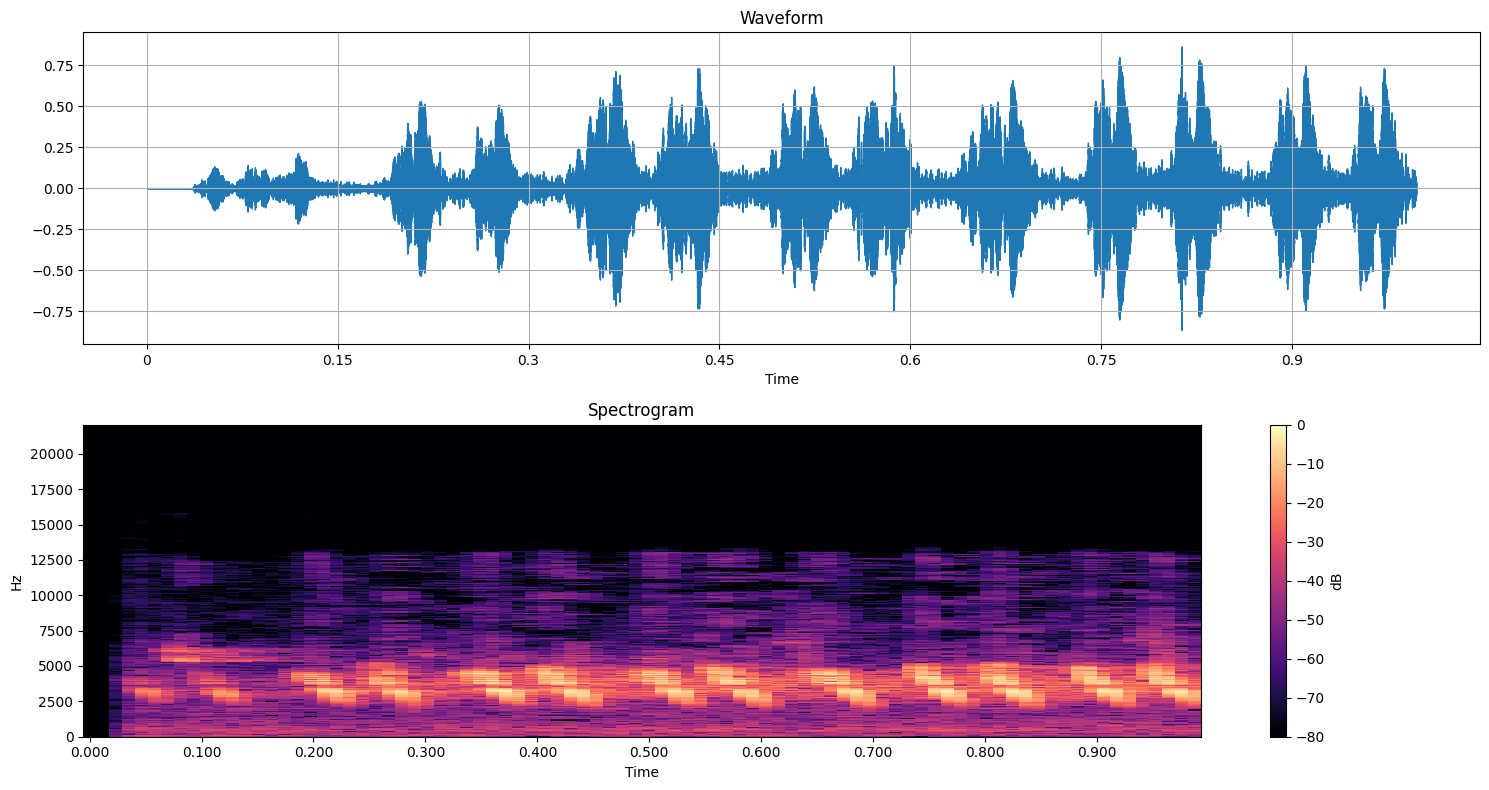

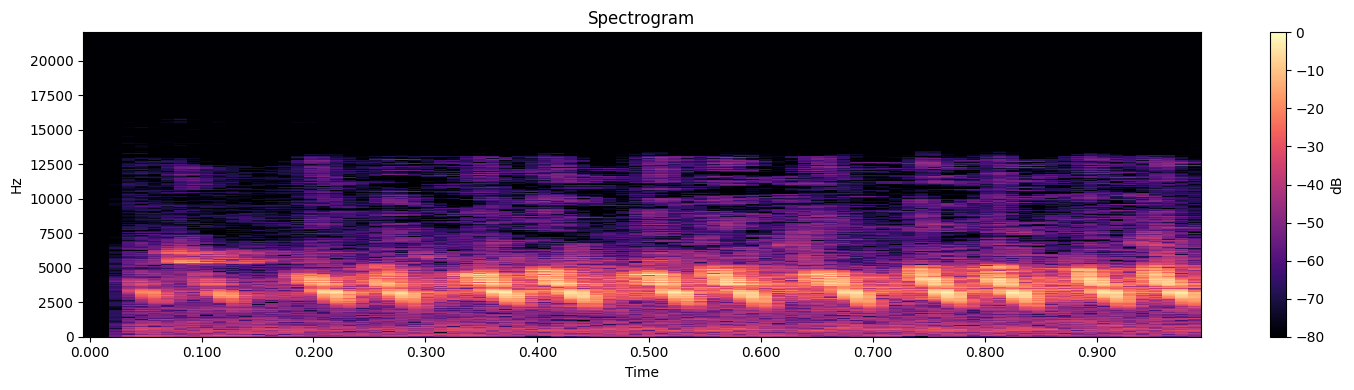

In [5]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np

#audio_file = "/content/input.wav"

def show_audio_wave_and_spec(y, sr):
  plt.figure(figsize=(15,8))

  # Waveform
  plt.subplot(2,1,1)
  librosa.display.waveshow(y, sr=sr)
  plt.title("Waveform")
  plt.grid(True)

  # Spectrogram
  D = librosa.amplitude_to_db(
      np.abs(librosa.stft(y)),
      ref=np.max
  )

  plt.subplot(2,1,2)
  librosa.display.specshow(
      D,
      sr=sr,
      x_axis='time',
      y_axis='hz',
      cmap='magma'
  )
  plt.colorbar(label='dB')
  plt.title("Spectrogram")

  plt.tight_layout()
  plt.show()

def show_audio_spectro(y, sr):
  plt.figure(figsize=(15,4))

  # Spectrogram
  D = librosa.amplitude_to_db(
      np.abs(librosa.stft(y)),
      ref=np.max
  )

  librosa.display.specshow(
      D,
      sr=sr,
      x_axis='time',
      y_axis='hz',
      cmap='magma'
  )
  plt.colorbar(label='dB')
  plt.title("Spectrogram")

  plt.tight_layout()
  plt.show()

y, sr = librosa.load(audio_file, sr=None)
show_audio_wave_and_spec(y[0:44000],sr)
show_audio_spectro(y[0:44000],sr)



### BAND PASS FILTERS

| Source          |              Suggested Band |
| --------------- | --------------------------: |
| Human speech    |                 300–4000 Hz |
| Children        |                 250–6000 Hz |
| Birds           |               1000–10000 Hz |
| Dogs            |                 200–8000 Hz |
| Unknown species | 50 Hz to 0.45 × sample_rate |




In [6]:
# band pass filter

import numpy as np
from scipy.signal import butter, filtfilt

def bandpass_filter(signal,
                    sample_rate,
                    lowcut=300,
                    highcut=4000,
                    order=4):
    """
    Butterworth zero-phase band-pass filter.

    Parameters
    ----------
    signal : np.ndarray
        1D audio signal.
    sample_rate : int
        Sample rate in Hz.
    lowcut : float
        Low cutoff frequency (Hz).
    highcut : float
        High cutoff frequency (Hz).
    order : int
        Filter order.

    Returns
    -------
    np.ndarray
        Filtered signal.
    """

    signal = np.asarray(signal, dtype=np.float32)

    nyquist = sample_rate * 0.5

    low = lowcut / nyquist
    high = highcut / nyquist

    if low <= 0:
        low = 1e-6
    if high >= 1:
        high = 0.999999

    b, a = butter(order, [low, high], btype="band")

    return filtfilt(b, a, signal)

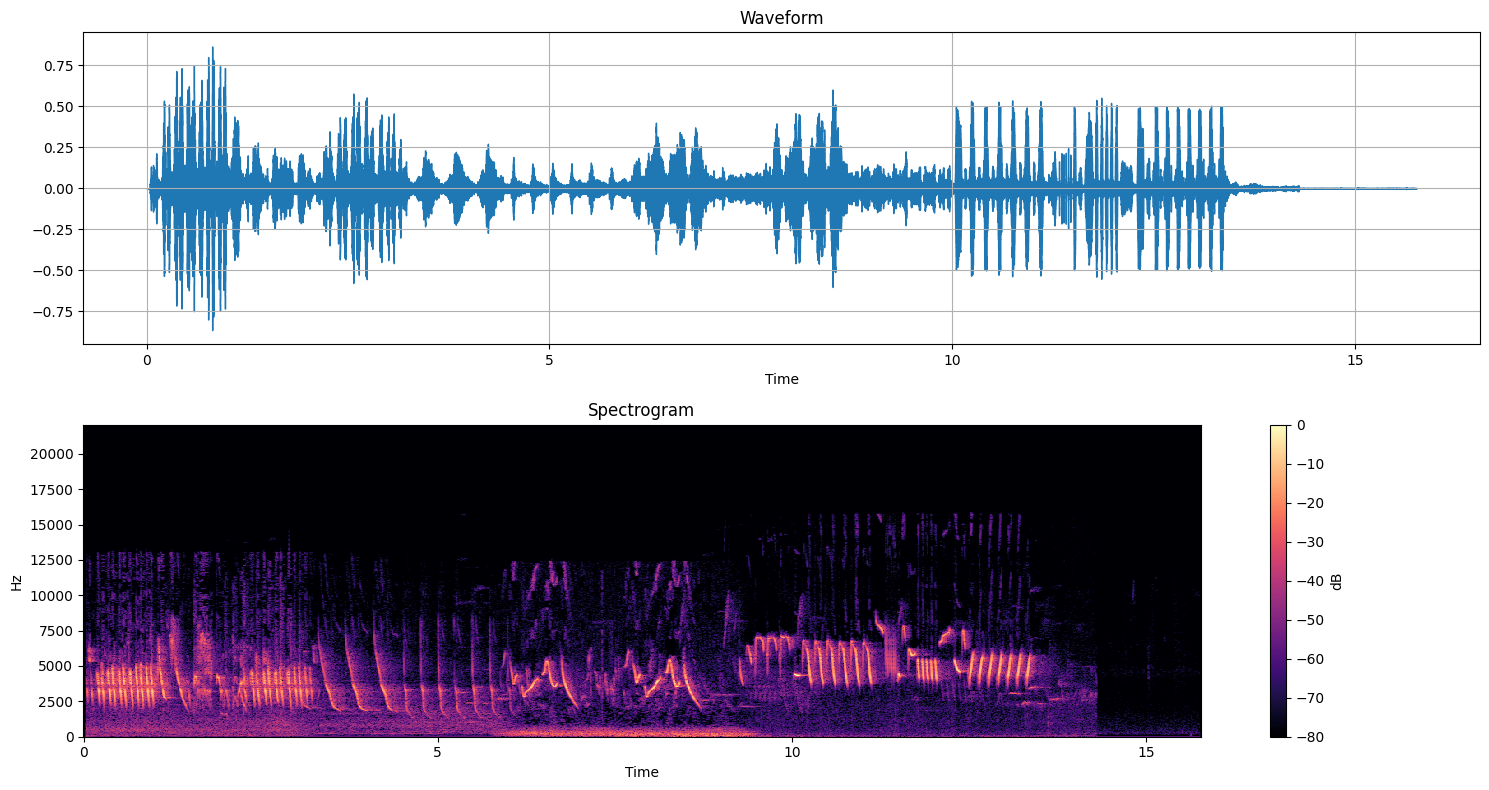

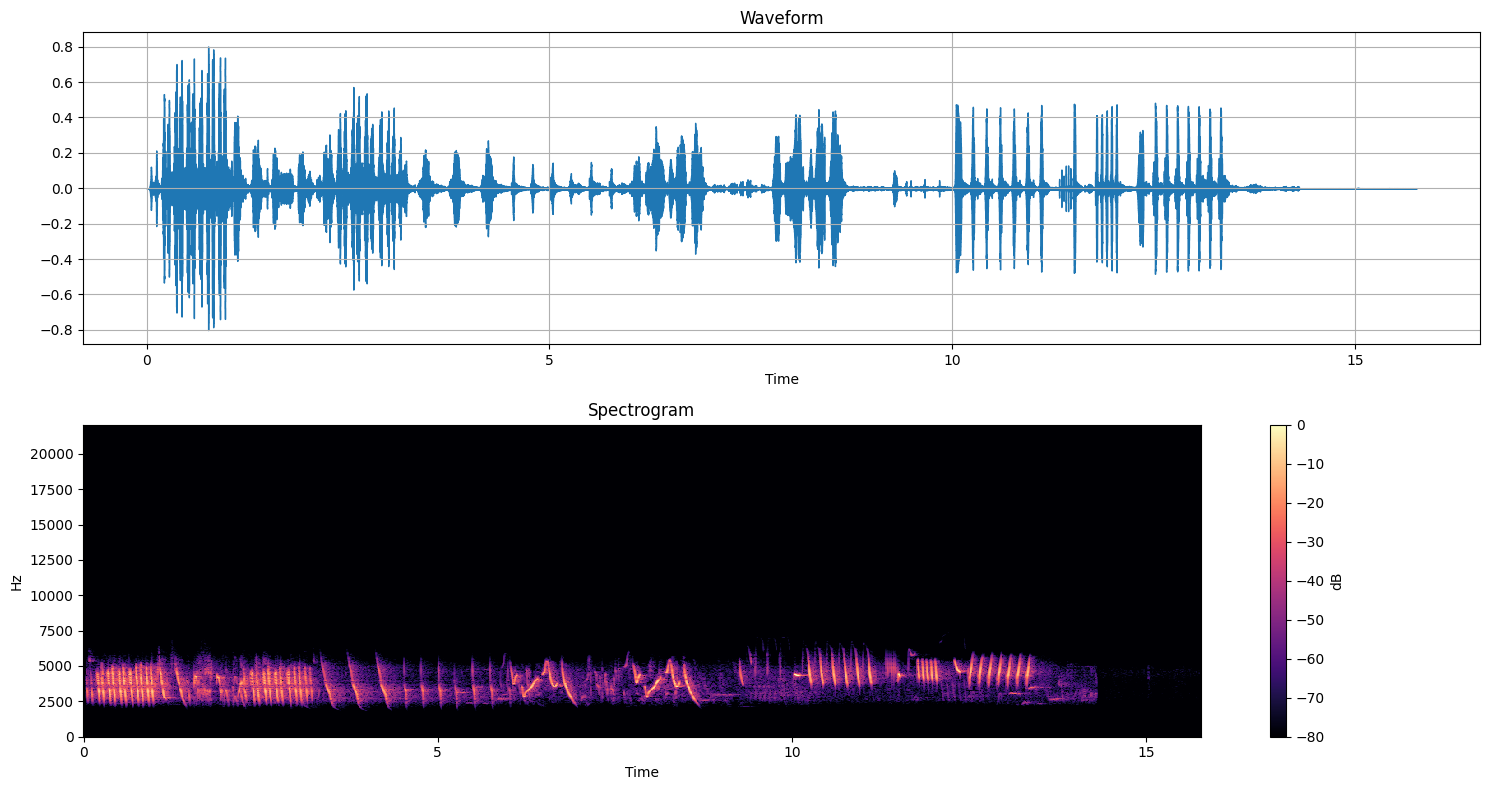

In [7]:
#band pass tests
filtered = bandpass_filter(
    y,
    sample_rate=sr,
    lowcut=2500,
    highcut=5000
)

show_audio_wave_and_spec(y,sr)
show_audio_wave_and_spec(filtered,sr)


ENERGY ACCUMULATION


Sample Rate: 44100
Duration: 1.41 seconds
Samples: 62000


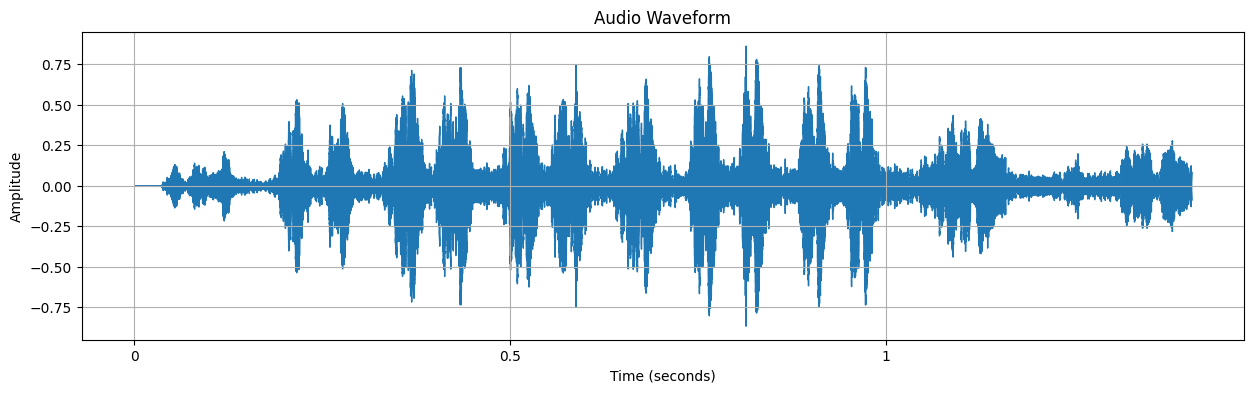

Sample Rate: 44100
Duration: 1.41 seconds
Samples: 62000


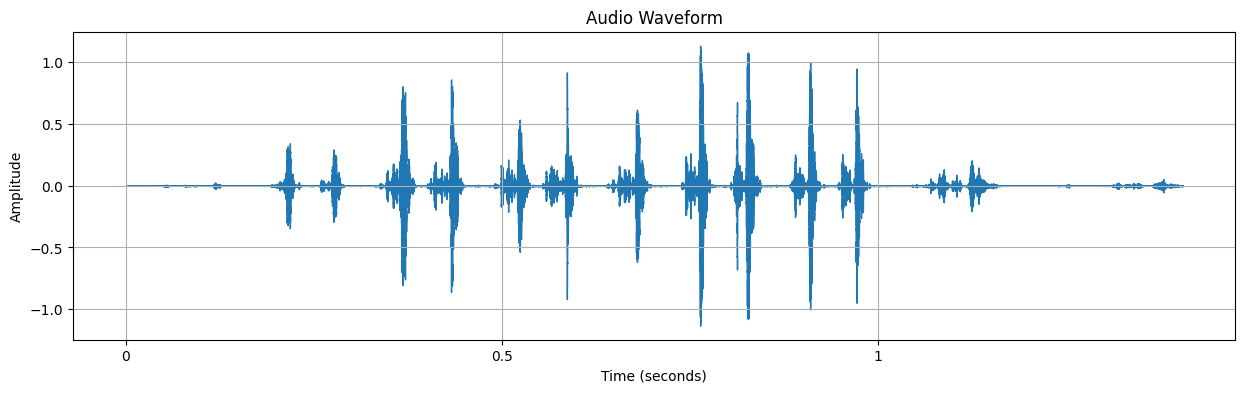

Sample Rate: 44100
Duration: 1.41 seconds
Samples: 62000


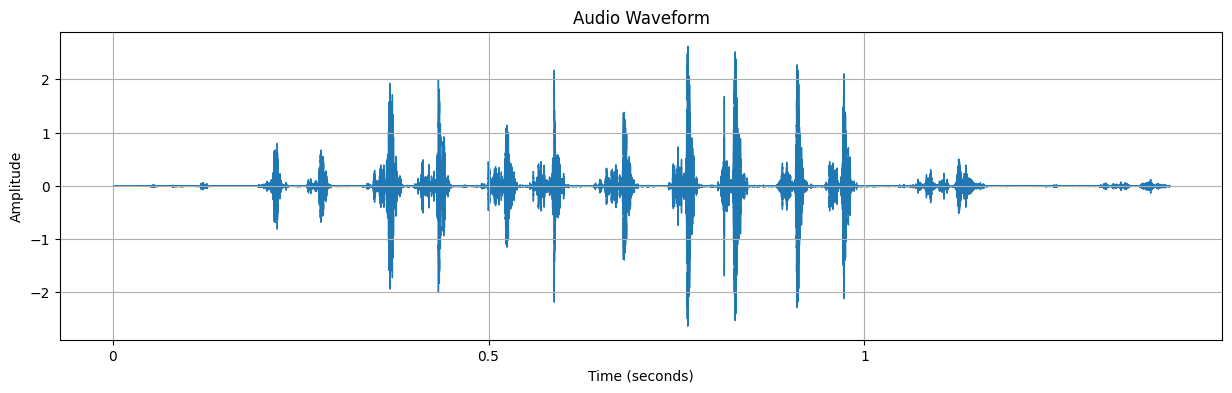

Sample Rate: 44100
Duration: 1.41 seconds
Samples: 62000


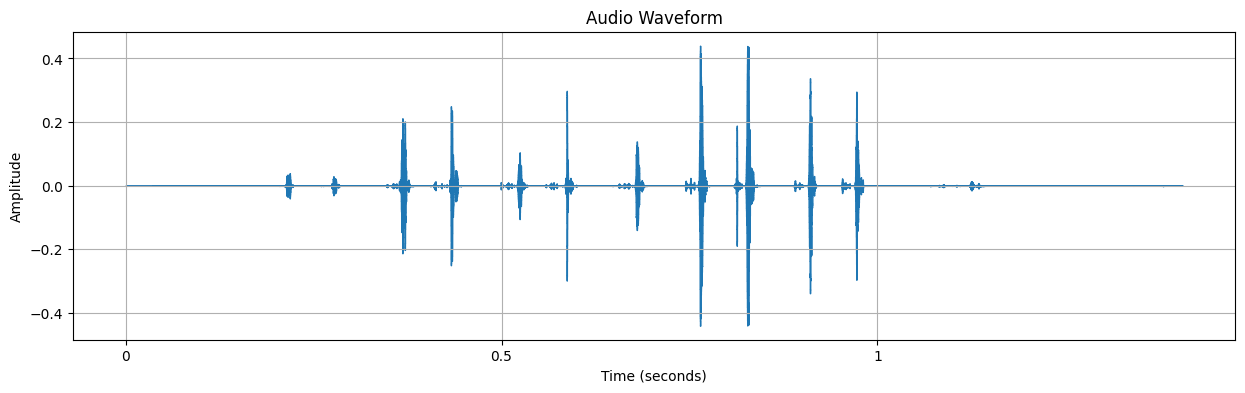

In [8]:
import numpy as np
import math

def accumulate_energy(signal, radius=5, decay=0.8, normalize=False):
    """
    Accumulate energy from nearby samples.

    Parameters
    ----------
    signal : np.ndarray
        1D input array.
    radius : int
        Number of neighbors on each side.
    decay : float
        Weight decay per distance.
        1.0 = equal weights
        0.8 = exponential decay
        0.0 = only current sample
    normalize : bool
        Divide by total weights.

    Returns
    -------
    np.ndarray
        Energy accumulated at each position.
    """
    signal = np.asarray(signal, dtype=np.float32)

    distances = np.arange(-radius, radius + 1)
    weights = decay ** np.abs(distances)

    #weights = np.log10(weights)

    if normalize:
        weights /= weights.sum()

    return np.convolve(signal, weights, mode="same")

def local_energy(signal, radius=5):
    signal = np.asarray(signal, dtype=np.float32)
    energy = signal ** 3
    kernel = np.ones(2 * radius + 1)
    return np.convolve(energy, kernel, mode="same")

import numpy as np

def gaussian_local_energy(signal, sigma=20, radius=None, normalize=True):
    """
    Gaussian-weighted local energy envelope.

    Parameters
    ----------
    signal : np.ndarray
        1D audio waveform.
    sigma : float
        Standard deviation of Gaussian (samples).
    radius : int or None
        Kernel radius. Default = 3*sigma.
    normalize : bool
        Normalize kernel to sum to 1.

    Returns
    -------
    np.ndarray
        Smoothed local energy envelope.
    """

    signal = np.asarray(signal, dtype=np.float32)

    # Instantaneous energy
    energy = signal ** 2

    if radius is None:
        radius = int(np.ceil(3 * sigma))

    x = np.arange(-radius, radius + 1)

    kernel = np.exp(-(x ** 2) / (2 * sigma ** 2))

    if normalize:
        kernel /= kernel.sum()

    envelope = np.convolve(energy, kernel, mode="same")

    return envelope

show_audio(y[0:62000],sr)

#energy = accumulate_energy(y[0:22000],radius=20, decay=0.5,  normalize=False);
energy = local_energy(y[0:62000],radius=5);
#print(energy)
show_audio(energy,sr)

acc_energy = accumulate_energy(energy,radius=50, decay=0.59,  normalize=False);
show_audio(acc_energy,sr)


gl_energy = gaussian_local_energy(energy,  sigma=5, radius=50)
show_audio(gl_energy,sr)

Gaussian RMS


| Audio Type       |  sigma_ms |
| ---------------- | --------: |
| Fast speech      |     10–15 |
| Normal speech    |    **20** |
| Slow speech      |        30 |
| Bird calls       |      5–10 |
| Whale sounds     |    50–200 |
| Unknown language | **20–30** |




In [9]:
import numpy as np

def gaussian_rms_envelope(audio,
                          sigma_ms=20,
                          sample_rate=16000,
                          truncate=3.0):
    """
    Compute a Gaussian-smoothed RMS energy envelope.

    Parameters
    ----------
    audio : np.ndarray
        1D mono audio signal.

    sigma_ms : float
        Gaussian sigma in milliseconds.
        Typical:
            10 ms = follows syllables closely
            20 ms = speech (recommended)
            40 ms = smoother envelope

    sample_rate : int
        Audio sample rate.

    truncate : float
        Kernel radius = truncate * sigma.

    Returns
    -------
    envelope : np.ndarray
        RMS energy envelope.
    """

    audio = np.asarray(audio, dtype=np.float32)

    # Convert milliseconds to samples
    sigma = sigma_ms * sample_rate / 1000.0

    radius = int(np.ceil(truncate * sigma))

    # Gaussian kernel
    x = np.arange(-radius, radius + 1)

    kernel = np.exp(-(x ** 2) / (2 * sigma ** 2))
    kernel /= kernel.sum()

    # Instantaneous power
    power = audio * audio

    # Smooth power
    smooth_power = np.convolve(power, kernel, mode="same")

    # RMS
    envelope = np.sqrt(smooth_power + 1e-12)

    return envelope


import matplotlib.pyplot as plt

def show_envelope_on_bpf_filtered(bpf_audio, envelope_aud ):
  plt.figure(figsize=(18,5))

  plt.plot(bpf_audio,
          alpha=0.35,
          label="Filtered audio")

  plt.plot(envelope_aud,
          linewidth=2,
          label="Gaussian RMS")

  plt.legend()

  plt.tight_layout()
  plt.show()

Adaptive threshold

In [10]:
import numpy as np

def adaptive_threshold(envelope,
                       sensitivity=3.0,
                       smooth=0):
    """
    Compute an adaptive threshold for an energy envelope.

    Parameters
    ----------
    envelope : np.ndarray
        Gaussian RMS or energy envelope.
    sensitivity : float
        Higher values -> fewer detected words.
        Lower values -> more sensitive.
        Typical: 2.0 to 4.0
    smooth : int
        Optional moving-average smoothing of threshold.
        0 = constant threshold.

    Returns
    -------
    threshold : np.ndarray
        Threshold array (same length as envelope).
    """

    envelope = np.asarray(envelope, dtype=np.float32)

    # Robust estimate of background energy
    median = np.median(envelope)

    mad = np.median(np.abs(envelope - median))

    # Convert MAD to standard deviation estimate
    sigma = 1.4826 * mad

    th = median + sensitivity * sigma

    threshold = np.full_like(envelope, th)

    if smooth > 1:
        kernel = np.ones(smooth, dtype=np.float32)
        kernel /= kernel.sum()
        threshold = np.convolve(threshold, kernel, mode="same")

    return threshold

# threshold = adaptive_threshold(
#     envelope,
#     sensitivity=2.8
# )

# speech_mask = envelope > threshold

import numpy as np
from scipy.ndimage import median_filter

def adaptive_threshold_local(envelope,
                             window=4000,
                             sensitivity=2.5):
    """
    Local adaptive threshold using rolling median + MAD.

    window : window size in samples
    """

    envelope = np.asarray(envelope, dtype=np.float32)

    med = median_filter(envelope, size=window, mode="reflect")

    deviation = np.abs(envelope - med)

    mad = median_filter(deviation, size=window, mode="reflect")

    sigma = 1.4826 * mad

    threshold = med + sensitivity * sigma

    return threshold

# threshold = adaptive_threshold_local(
#     envelope,
#     window=int(0.5 * sr),   # 500 ms window
#     sensitivity=2.5
# )

# speech_mask = envelope > threshold

Detect energy peaks

In [13]:
import numpy as np
from scipy.signal import find_peaks


def detect_energy_peaks(
    envelope,
    sample_rate,
    min_peak_distance_ms=80,
    threshold_factor=2.5,
    prominence_factor=1.0,
):
    """
    Detect peaks in an energy envelope.

    Parameters
    ----------
    envelope : np.ndarray
        Gaussian RMS envelope.

    sample_rate : int
        Sample rate in Hz.

    min_peak_distance_ms : float
        Minimum time between peaks.

    threshold_factor : float
        Threshold = median + threshold_factor * MAD

    prominence_factor : float
        Peak prominence multiplier.

    Returns
    -------
    peaks : np.ndarray
        Indices of detected peaks.

    properties : dict
        Properties returned by scipy.find_peaks().
    """

    envelope = np.asarray(envelope, dtype=np.float32)

    # ---------- Robust statistics ----------
    median = np.median(envelope)

    mad = np.median(np.abs(envelope - median))

    # Convert MAD to robust std estimate
    robust_std = 1.4826 * mad

    # ---------- Adaptive threshold ----------
    height = median + threshold_factor * robust_std

    prominence = prominence_factor * robust_std

    distance = int(sample_rate * min_peak_distance_ms / 1000)

    peaks, properties = find_peaks(
        envelope,
        height=height,
        distance=distance,
        prominence=prominence,
    )

    return peaks, properties


import matplotlib.pyplot as plt

def show_audio_energy_peaks(env, peaks):
  plt.figure(figsize=(18,4))

  plt.plot(env)

  plt.scatter(
      peaks,
      env[peaks],
      color="red",
      s=35,
      label="Peaks"
  )

  plt.legend()
  plt.show()

# env = gaussian_rms_envelope(audio, sigma=60)

# peaks, props = detect_energy_peaks(
#     env,
#     sample_rate=sr,
#     min_peak_distance_ms=80
# )

# print("Detected peaks:", len(peaks))

In [116]:
import numpy as np
# difference from x previous and x next
def sum_of_differences(arr,x_diff):
    n = len(arr)
    new_arr = [0] * n  # Initialize a new array of the same size as input
    for i in range(n):
        total_diff = 0
        # Consider elements in the range [i-5, i+5]
        for j in range(max(0, i - x_diff), min(n, i + x_diff+4-3)):
            if i != j:  # Exclude the current element
                total_diff += arr[i] - arr[j]
        if(total_diff<0):
          total_diff = 0
        new_arr[i] = total_diff
    return new_arr

# def sum_of_differences_np(arr,x_diff):
#   n = len(arr)
#   arr = np.array(arr)

#   mask_arr_ls = arr.copy()
#   mask_arr_rs = arr.copy()
#   new_arr = np.multiply(x_diff,arr)

#   for i in range(0, x_diff):
#     shifted_left = np.zeros_like(mask_arr_ls)
#     shifted_left[:-1] = mask_arr_ls[1:]
#     mask_arr_ls = shifted_left.copy()

#     shifted_right = np.zeros_like(mask_arr_rs)
#     shifted_right[1:] = mask_arr_rs[:-1]
#     mask_arr_rs = shifted_right.copy()

#     new_arr = np.subtract(new_arr,mask_arr_ls+mask_arr_rs)

#   return new_arr


def sum_of_differences_np(arr, x_diff):
    arr = np.asarray(arr)
    n = arr.size

    # Prefix sum with leading zero
    prefix = np.concatenate(([0], np.cumsum(arr)))

    idx = np.arange(n)

    # Left window [i-x, i)
    l0 = np.maximum(idx - x_diff, 0)
    left_sum = prefix[idx] - prefix[l0]

    # Right window (i, i+x]
    r1 = np.minimum(idx + x_diff + 1, n)
    right_sum = prefix[r1] - prefix[idx + 1]

    return 2 * x_diff * arr - left_sum - right_sum







# proximity zero out
def find_max_and_zero_out(arr_orig, proximity):
    arr = arr_orig.copy()
    n = len(arr)
    result = [0] * n  # Initialize the result array with zeros

    while any(arr):  # Continue until all elements in arr are 0
        # Find the index of the maximum value in the array
        max_index = arr.index(max(arr))
        # Store the maximum value in the result array at the same index
        result[max_index] = arr[max_index]
        # Zero out the elements within the proximity
        for i in range(max(0, max_index - proximity), min(n, max_index + proximity + 1)):
            arr[i] = 0

    return result

import numpy as np

def find_max_and_zero_out_Onlogn(arr, proximity):
    arr = np.asarray(arr)
    n = len(arr)

    result = np.zeros_like(arr)

    # Process indices from largest value to smallest
    order = np.argsort(arr)[::-1]

    blocked = np.zeros(n, dtype=bool)

    for idx in order:
        if arr[idx] <= 0:
            break                  # remaining values are zero or negative

        if blocked[idx]:
            continue

        result[idx] = arr[idx]

        left = max(0, idx - proximity)
        right = min(n, idx + proximity + 1)
        blocked[left:right] = True

    return result

```
Audio
↓
Bandpass
↓
Gaussian RMS
↓
Adaptive threshold
↓
Merge nearby peaks (<200 ms apart)
↓
Find minima between merged peaks
↓
Discard shallow minima
↓
Word candidates

```



/tmp/ipykernel_1365/901435762.py:9: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(audio_file, sr=16000)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


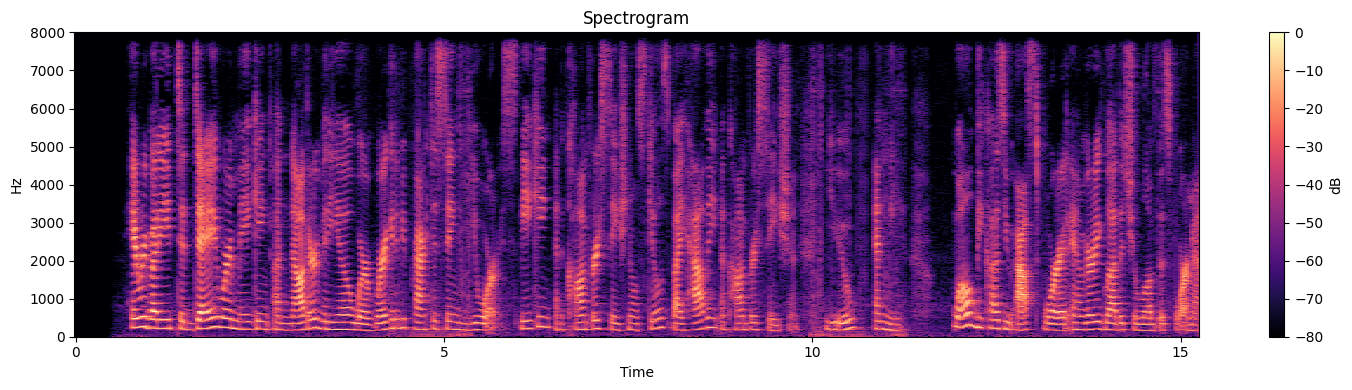

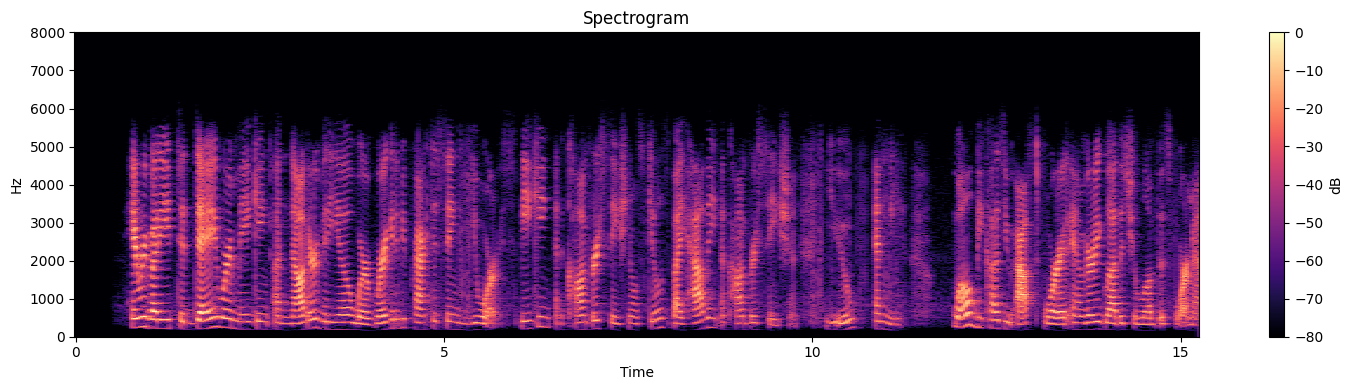

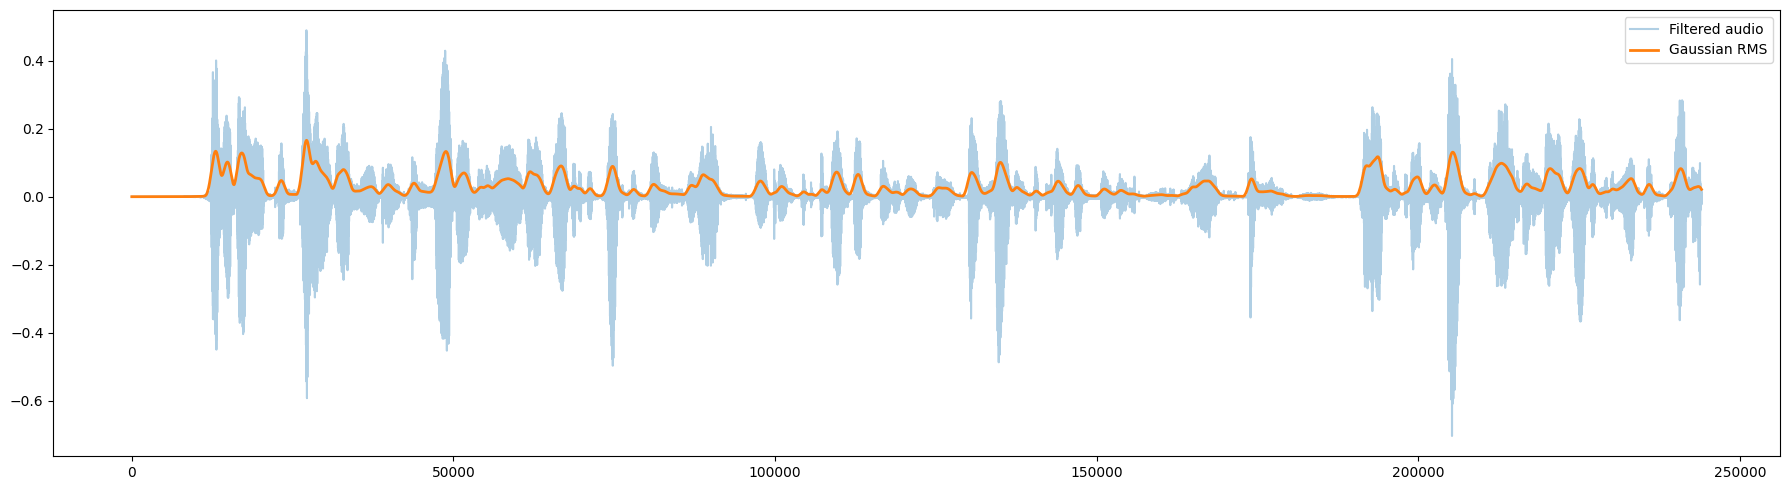

[0. 0. 0. ... 1. 1. 1.]
Sample Rate: 16000
Duration: 15.25 seconds
Samples: 244000


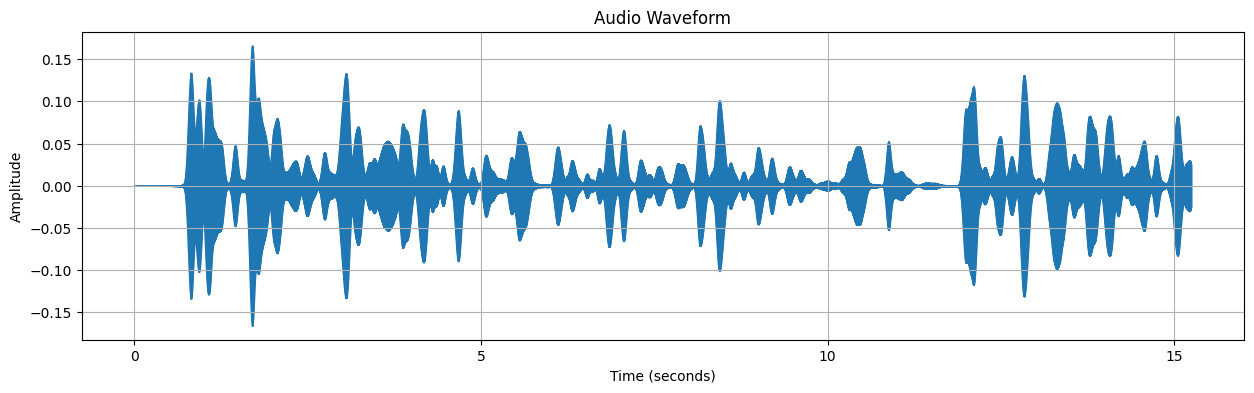

4.6. Finding peaks
Sample Rate: 16000
Duration: 15.25 seconds
Samples: 244000


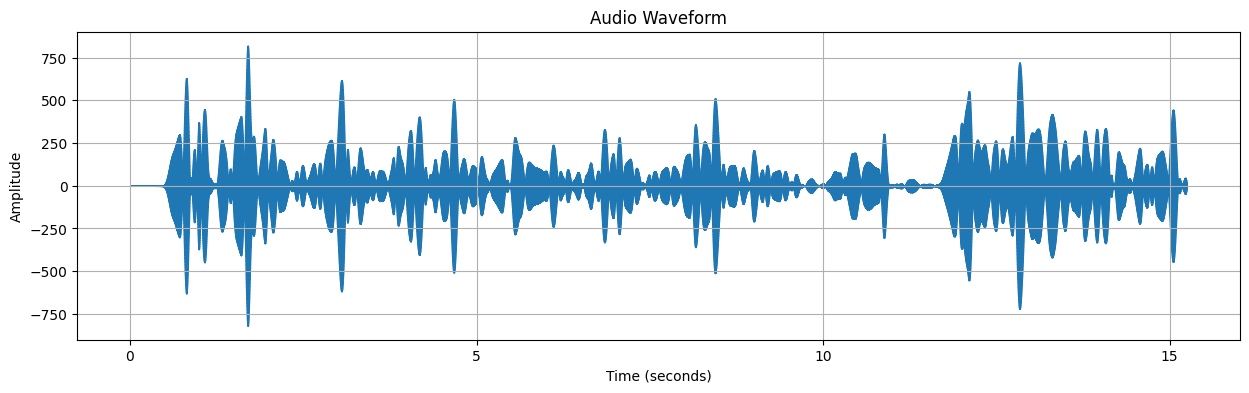

Sample Rate: 16000
Duration: 15.25 seconds
Samples: 244000


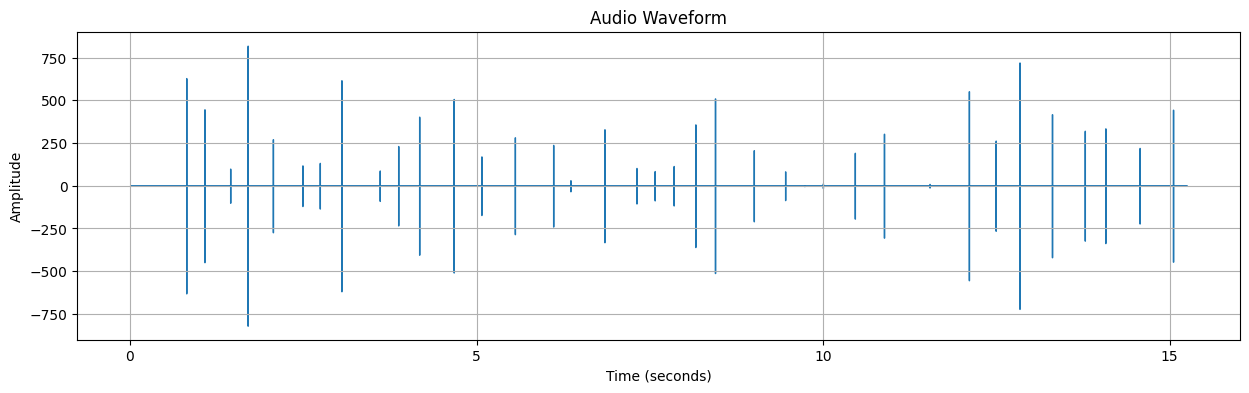

4.6. Finding peaks done
4.7. Finding trough
4.7. Finding trough done


In [132]:
import librosa
import numpy as np
import ruptures as rpt
from IPython.display import Audio, display, Markdown

#1. Audio
#audio_file = "/content/drive/MyDrive/colab_datas/isp_comm/bird_sound_shorts_1.m4a"
audio_file = "/content/drive/MyDrive/colab_datas/isp_comm/human_conversation.m4a"
y, sr = librosa.load(audio_file, sr=16000)
audio = y[0:244000]

show_audio_spectro(audio,sr)

#2. Bandpass
# for birds 2500 - 7000 for humans 300 - 4000

bpf_audio = bandpass_filter(
    audio,
    sample_rate=sr,
    lowcut=300,
    highcut=5000
)
show_audio_spectro(bpf_audio,sr)

#3. Gaussian RMS
# 7 for birds 20 for normal human speech

envelope_aud = gaussian_rms_envelope(
    bpf_audio,
    sigma_ms=20,
    sample_rate=sr
)

show_envelope_on_bpf_filtered(bpf_audio, envelope_aud)

#4. Adaptive threshold

# threshold = adaptive_threshold(
#     envelope_aud,
#     sensitivity=2.8
# )

threshold = adaptive_threshold_local(
    envelope_aud,
    window=int(0.04 * sr),   # 500 ms window
    sensitivity=2.5
)

#show_audio(threshold, sr)
speech_mask = np.where(envelope_aud > threshold, 0.0, 1.0)
print(speech_mask)
#show_audio(speech_mask, sr)

show_audio(envelope_aud,sr)

#4.5.
#env = gaussian_rms_envelope(audio, sigma=60)
# peaks, props = detect_energy_peaks(
#     envelope_aud,
#     sample_rate=sr,
#     min_peak_distance_ms=30
# )

# print("Detected peaks:", len(peaks))
# show_audio_energy_peaks(audio, peaks)

#4.6 find peaks
print("4.6. Finding peaks")
sd = sum_of_differences_np(envelope_aud,4000) # 400 for birds #4000 for human
mo0 = find_max_and_zero_out_Onlogn(sd.tolist(),4000) # 400 for birds #4000 for human
sd = np.array(sd)
#sd = sd * sd
show_audio(sd,sr)

show_audio(np.array(mo0),sr)
print("4.6. Finding peaks done")

#4.7. find trough
print("4.7. Finding trough")
rev_envelope_aud = np.subtract(1,envelope_aud)
rev_sd = sum_of_differences_np(rev_envelope_aud.tolist(),4000) # 400 for birds #400 for human
rev_mo0 = find_max_and_zero_out_Onlogn(rev_sd,4000)
rev_sd = np.array(rev_sd)
print("4.7. Finding trough done")





#5. Merge nearby peaks (<200 ms apart)
#6. Find minima between merged peaks
#7. Discard shallow minima
#8. Word candidates

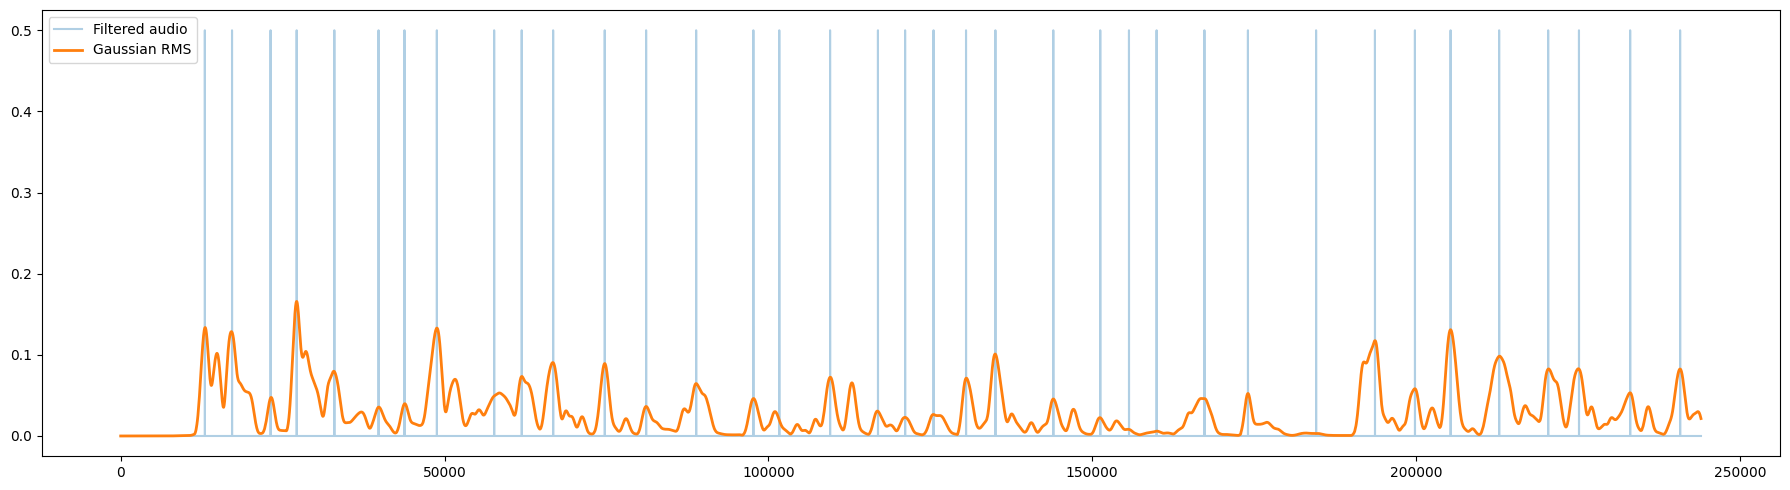

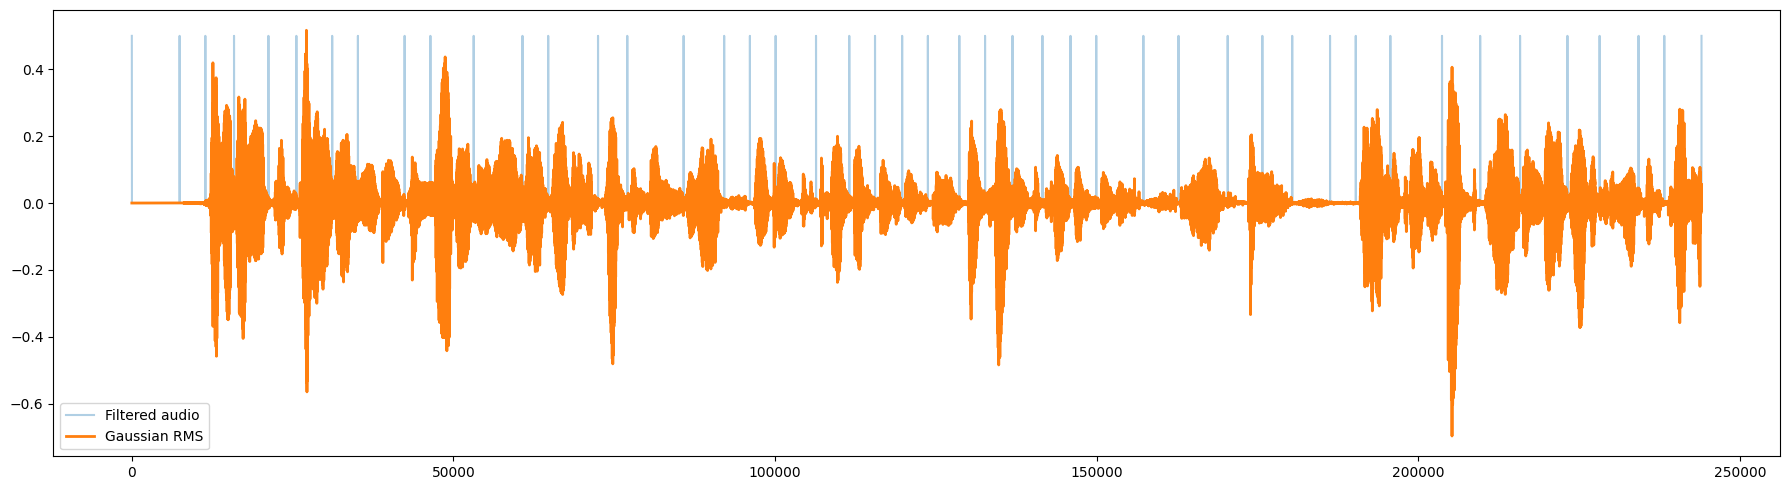

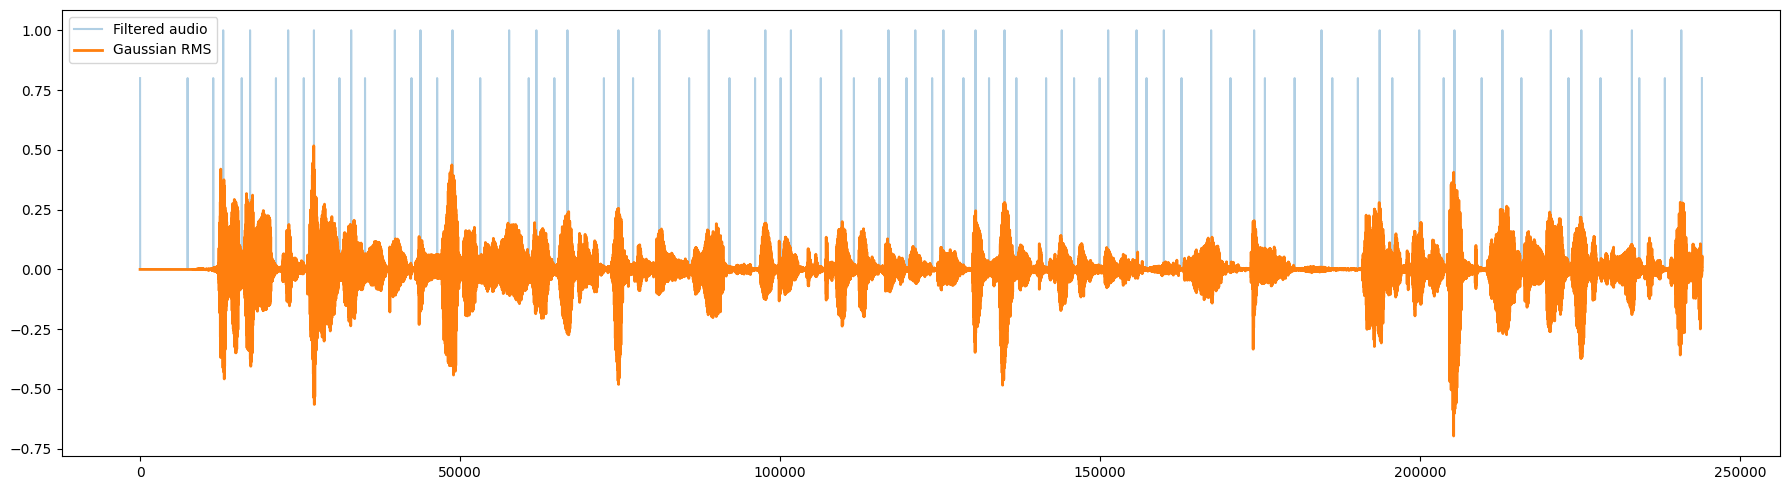

Sample Rate: 16000
Duration: 15.25 seconds
Samples: 244000


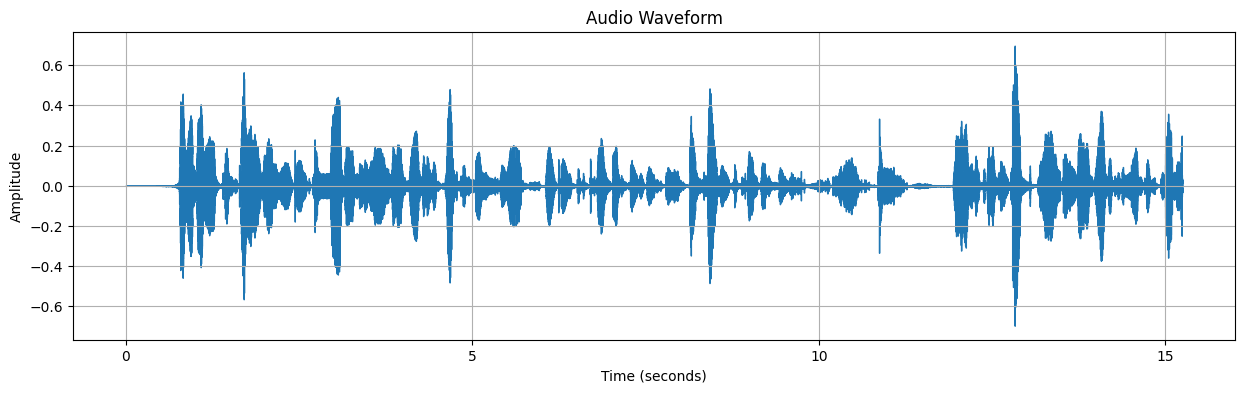

In [133]:
peak_mask = np.where(np.array(mo0) > 1, 0.5, 0.0)
show_envelope_on_bpf_filtered(peak_mask,envelope_aud)

trough_mask = np.where(np.array(rev_mo0) > 1, 0.5, 0.0)
show_envelope_on_bpf_filtered(trough_mask,audio)

both_mask = np.where( peak_mask > 0.3, 1.0, 0.0) + np.where( trough_mask > 0.3, 0.8, 0.0)
show_envelope_on_bpf_filtered(both_mask,audio)

show_audio(audio,sr)






#8. Word candidates

In [134]:
# mask to word
# both_mask
def find_intervals(arr):
    stack = []
    intervals = []

    seen_one = False

    for i, v in enumerate(arr):

        if v == 0.8:
            if stack:
                if seen_one:
                    intervals.append((stack[-1], i))
                stack.pop()

            stack.append(i)
            seen_one = False

        elif v == 1.0:
            if stack:
                seen_one = True

    return intervals

def find_intervals_lm(arr):
    last08 = -1
    seen_one = False
    intervals = []

    for i, v in enumerate(arr):
        if v == 0.8:
            if last08 != -1 and seen_one:
                intervals.append((last08, i))
            last08 = i
            seen_one = False

        elif v == 1.0 and last08 != -1:
            seen_one = True

    return intervals

intervals = find_intervals(both_mask)
intervalsX = find_intervals_lm(both_mask)
print(intervals)
print(intervalsX)


[(11428, 15885), (15885, 21231), (21231, 25578), (25578, 31143), (31143, 35144), (35144, 42404), (42404, 46410), (46410, 53140), (53140, 60722), (60722, 64723), (64723, 72467), (72467, 77015), (77015, 85773), (85773, 92075), (96076, 100077), (100077, 106353), (106353, 111523), (115524, 119740), (119740, 123741), (123741, 128628), (128628, 132629), (132629, 136897), (141546, 145912), (149913, 157237), (157237, 162703), (162703, 170347), (170347, 175732), (180374, 186254), (190255, 195628), (195628, 203660), (203660, 209592), (209592, 215793), (215793, 223155), (223155, 228160), (228160, 234211), (238212, 243999)]
[(11428, 15885), (15885, 21231), (21231, 25578), (25578, 31143), (31143, 35144), (35144, 42404), (42404, 46410), (46410, 53140), (53140, 60722), (60722, 64723), (64723, 72467), (72467, 77015), (77015, 85773), (85773, 92075), (96076, 100077), (100077, 106353), (106353, 111523), (115524, 119740), (119740, 123741), (123741, 128628), (128628, 132629), (132629, 136897), (141546, 145

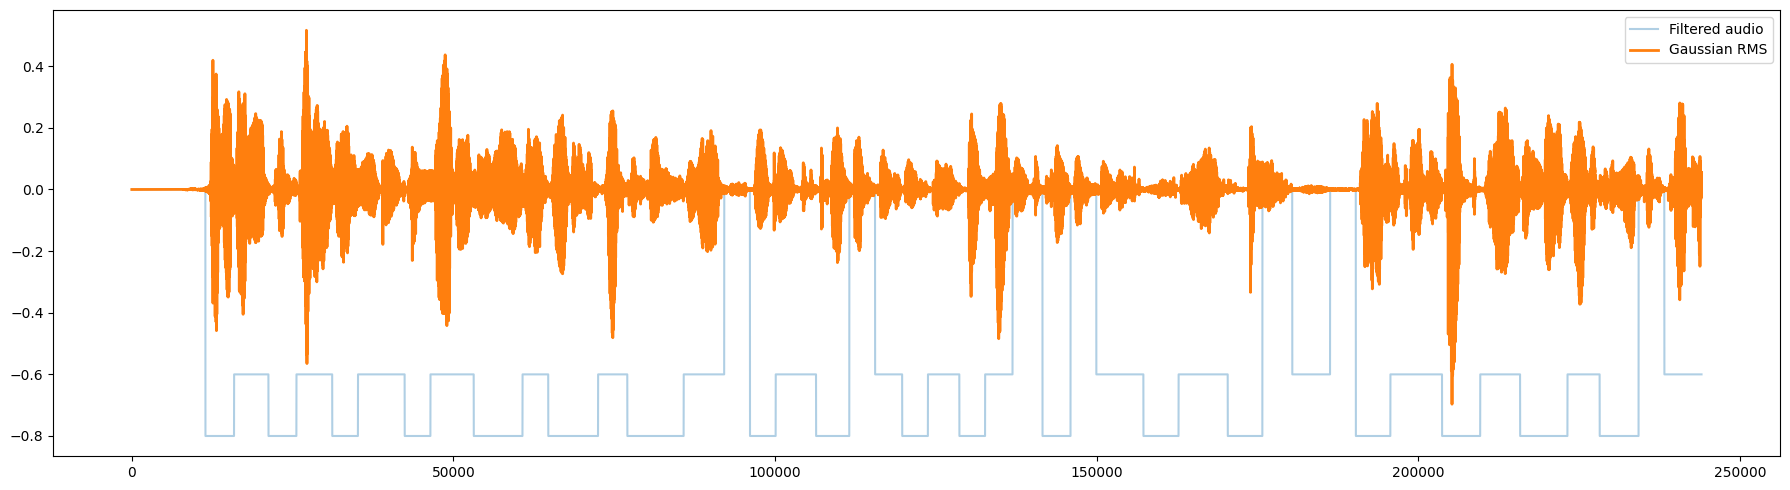

In [135]:
def create_interval_mask(intervals, size, values=(-0.8, -0.6)):
    mask = [0] * size

    toggle = 0

    for start, end in intervals:
        for i in range(start, end + 1):
            mask[i] = values[toggle]

        toggle = 1 - toggle   # alternate for next interval

    return mask

selected_word_mask = create_interval_mask(intervals, len(both_mask))
show_envelope_on_bpf_filtered(selected_word_mask,audio)

Detected 11 candidate segments

11428-15885


### Segment 11
- Start: **0.71 s**
- End: **0.99 s**
- Duration: **0.30 s**

Sample Rate: 16000
Duration: 0.30 seconds
Samples: 4857


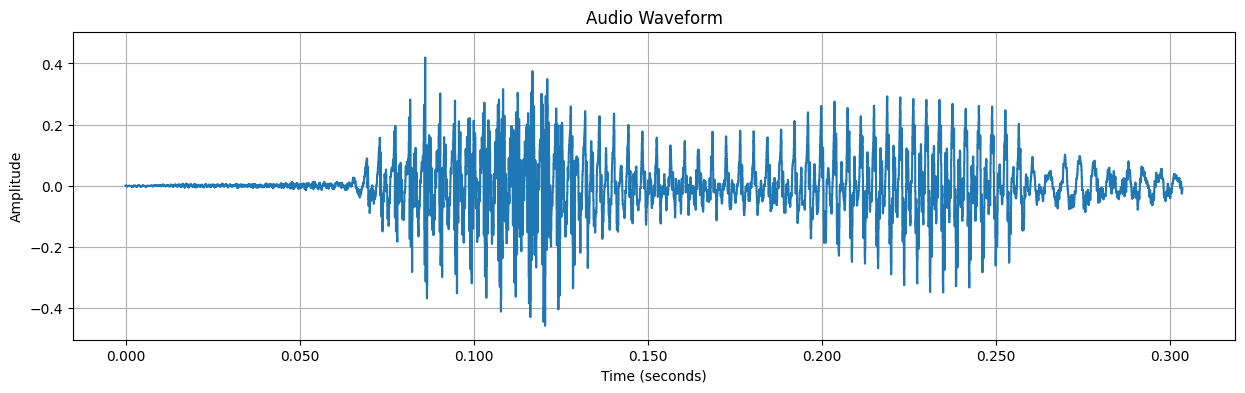

15885-21231


### Segment 11
- Start: **0.99 s**
- End: **1.33 s**
- Duration: **0.36 s**

Sample Rate: 16000
Duration: 0.36 seconds
Samples: 5746


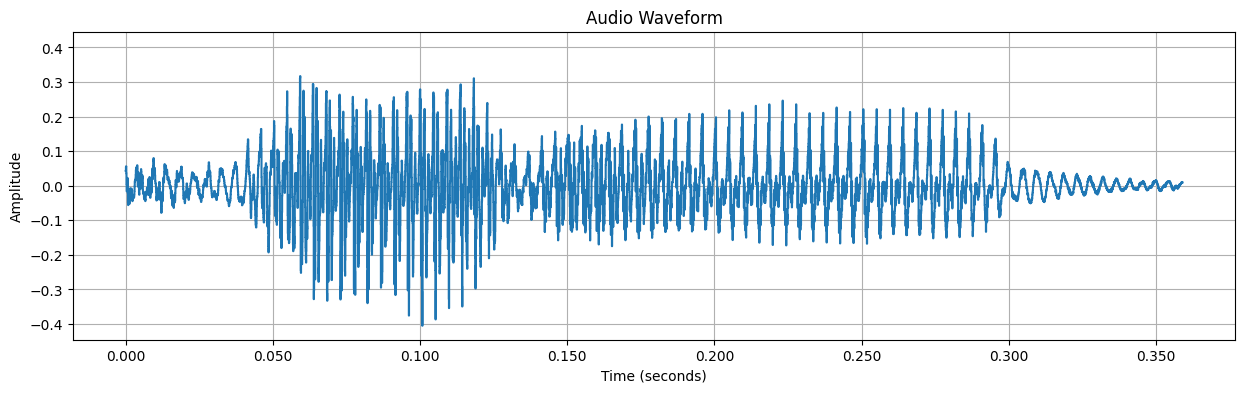

21231-25578


### Segment 11
- Start: **1.33 s**
- End: **1.60 s**
- Duration: **0.30 s**

Sample Rate: 16000
Duration: 0.30 seconds
Samples: 4747


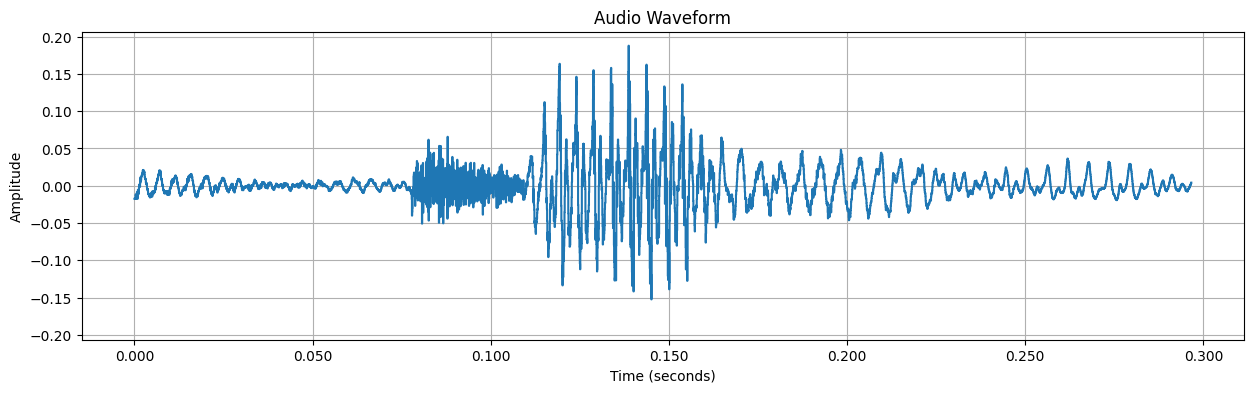

25578-31143


### Segment 11
- Start: **1.60 s**
- End: **1.95 s**
- Duration: **0.37 s**

Sample Rate: 16000
Duration: 0.37 seconds
Samples: 5965


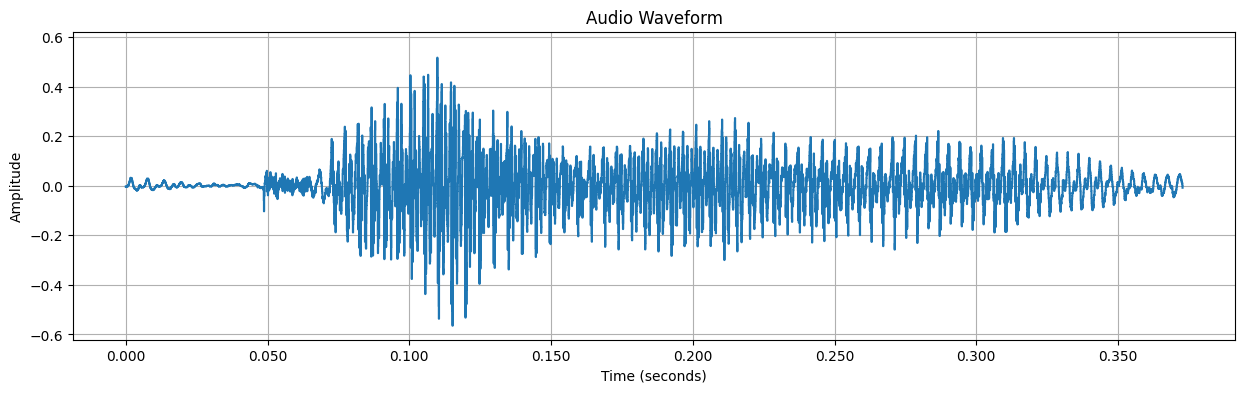

31143-35144


### Segment 11
- Start: **1.95 s**
- End: **2.20 s**
- Duration: **0.28 s**

Sample Rate: 16000
Duration: 0.28 seconds
Samples: 4401


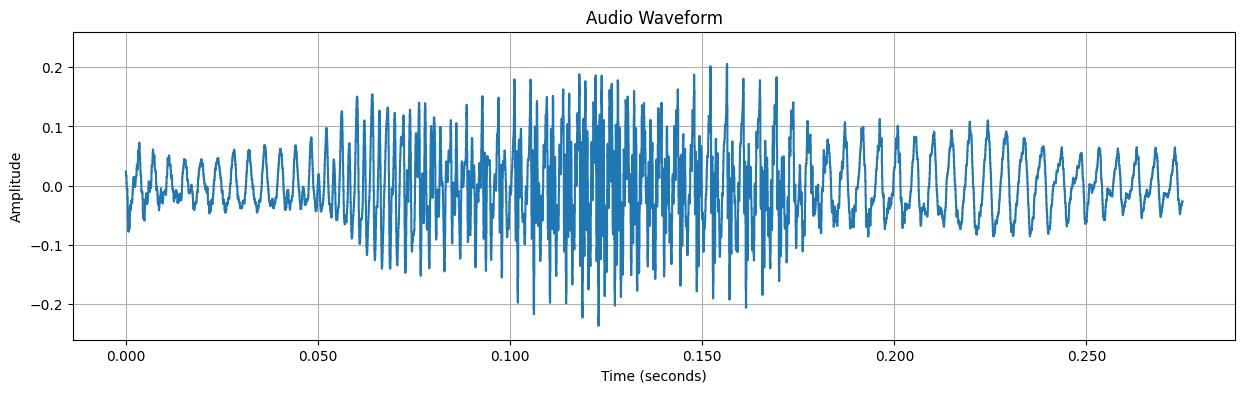

35144-42404


### Segment 11
- Start: **2.20 s**
- End: **2.65 s**
- Duration: **0.48 s**

Sample Rate: 16000
Duration: 0.48 seconds
Samples: 7660


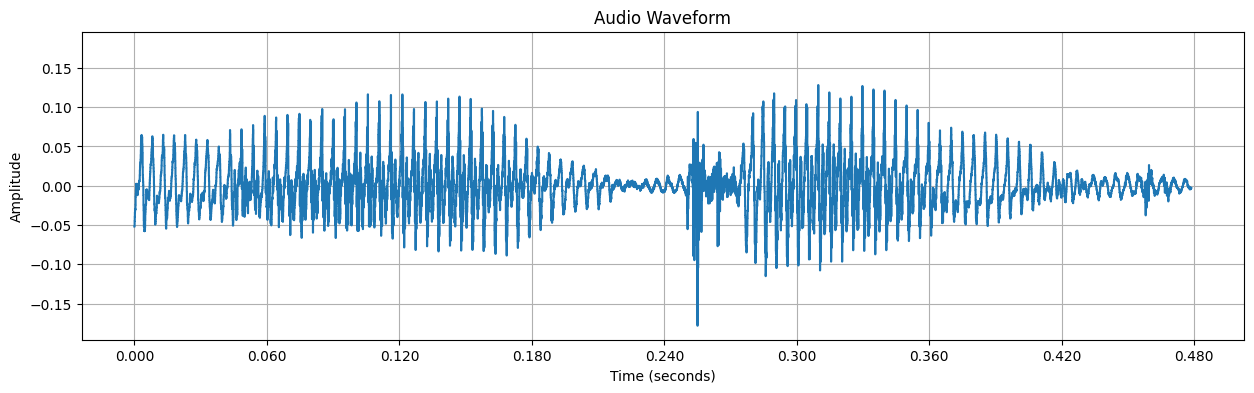

42404-46410


### Segment 11
- Start: **2.65 s**
- End: **2.90 s**
- Duration: **0.28 s**

Sample Rate: 16000
Duration: 0.28 seconds
Samples: 4406


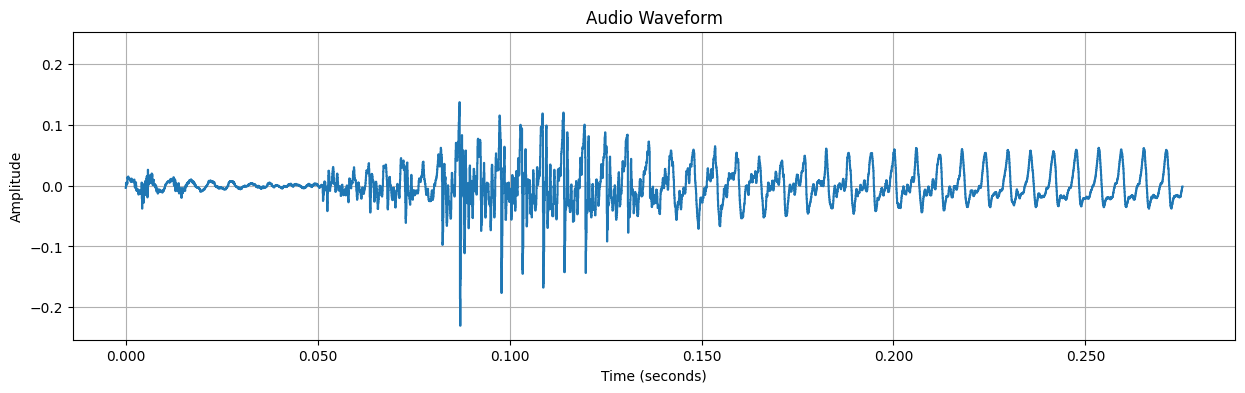

46410-53140


### Segment 11
- Start: **2.90 s**
- End: **3.32 s**
- Duration: **0.45 s**

Sample Rate: 16000
Duration: 0.45 seconds
Samples: 7130


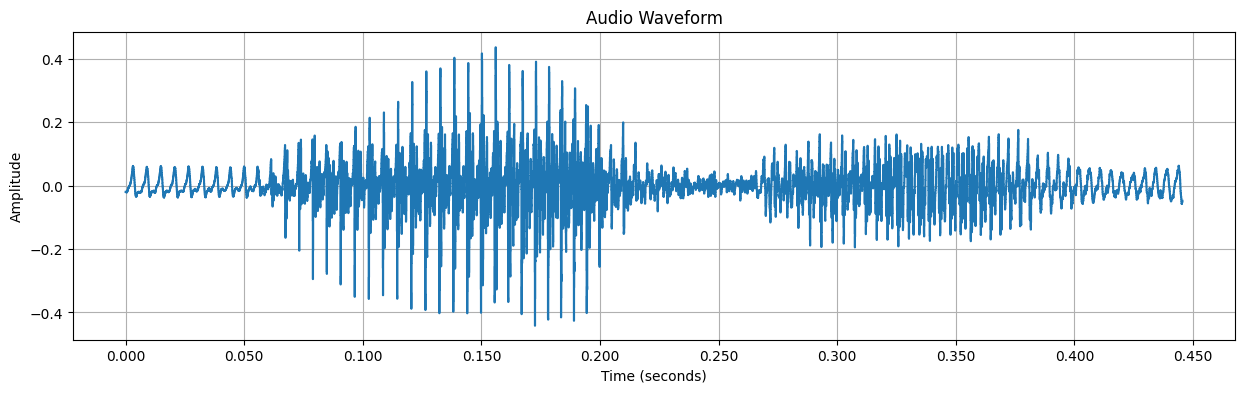

53140-60722


### Segment 11
- Start: **3.32 s**
- End: **3.80 s**
- Duration: **0.50 s**

Sample Rate: 16000
Duration: 0.50 seconds
Samples: 7982


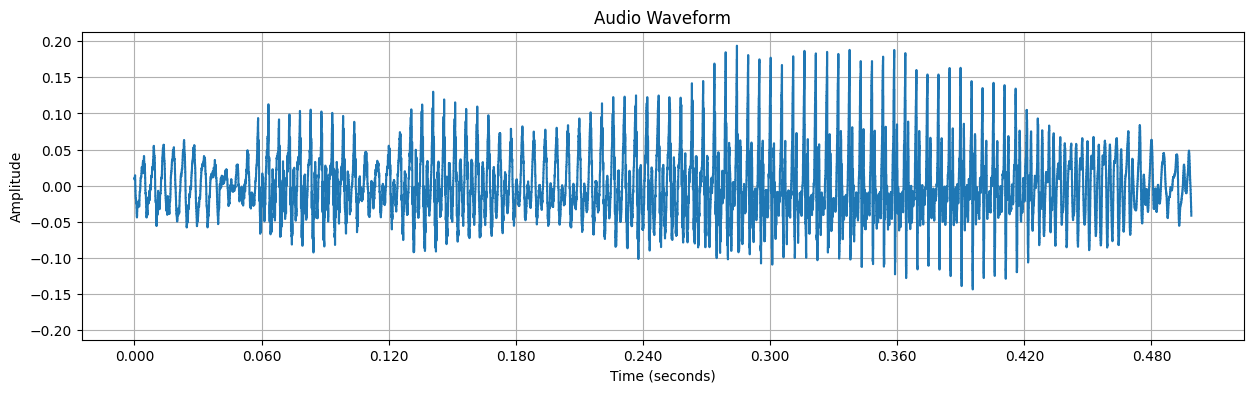

60722-64723


### Segment 11
- Start: **3.80 s**
- End: **4.05 s**
- Duration: **0.28 s**

Sample Rate: 16000
Duration: 0.28 seconds
Samples: 4401


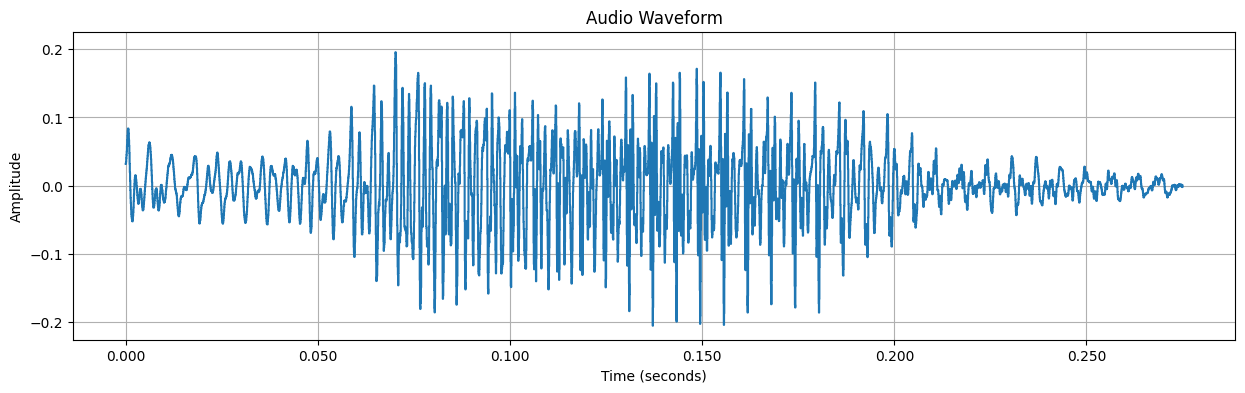

64723-72467


### Segment 11
- Start: **4.05 s**
- End: **4.53 s**
- Duration: **0.51 s**

Sample Rate: 16000
Duration: 0.51 seconds
Samples: 8144


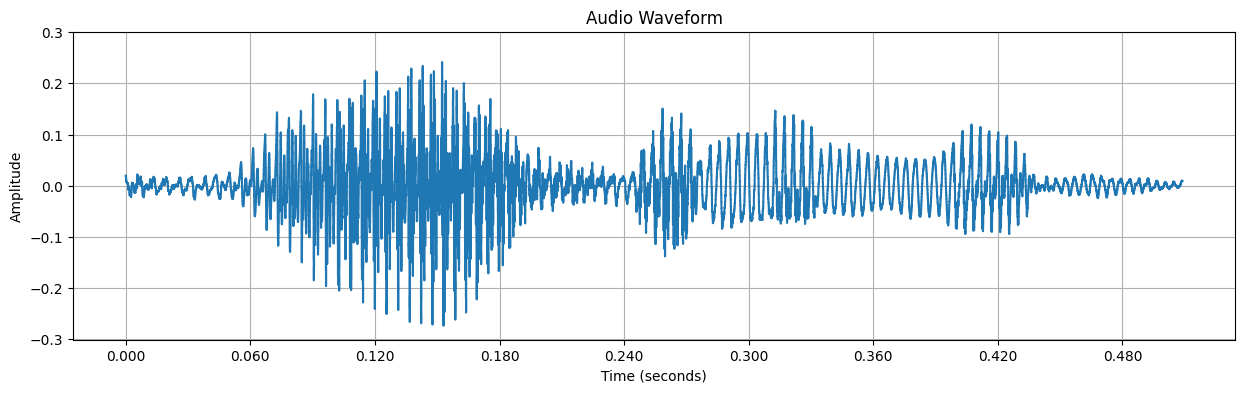

72467-77015


### Segment 11
- Start: **4.53 s**
- End: **4.81 s**
- Duration: **0.31 s**

Sample Rate: 16000
Duration: 0.31 seconds
Samples: 4948


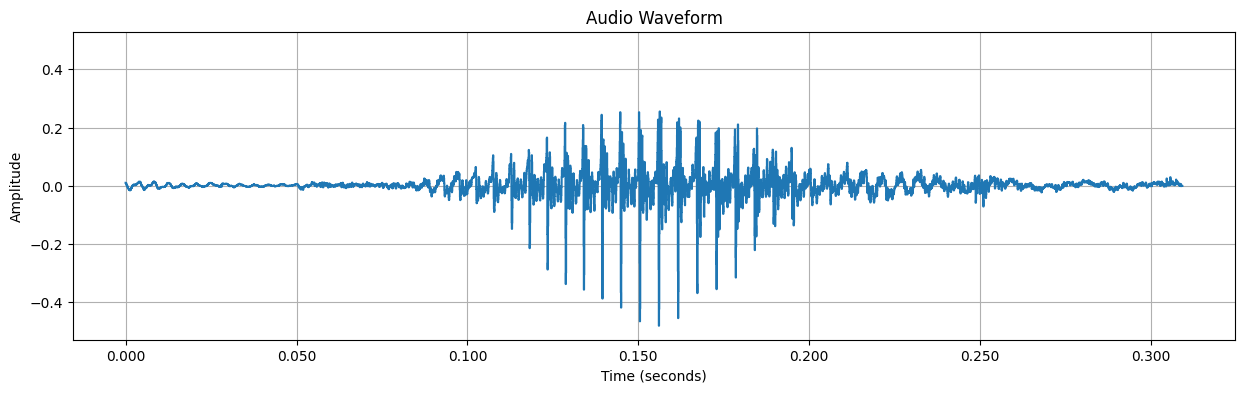

77015-85773


### Segment 11
- Start: **4.81 s**
- End: **5.36 s**
- Duration: **0.57 s**

Sample Rate: 16000
Duration: 0.57 seconds
Samples: 9158


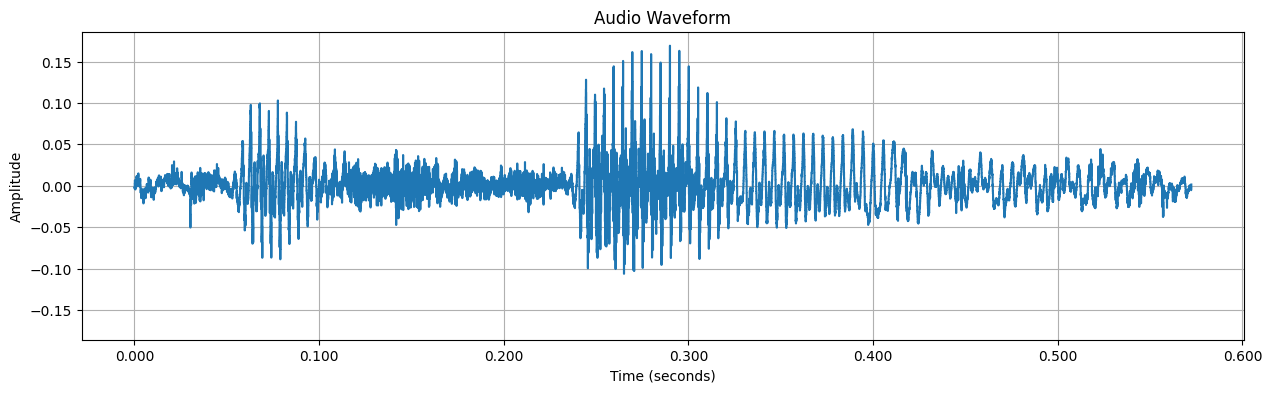

85773-92075


### Segment 11
- Start: **5.36 s**
- End: **5.75 s**
- Duration: **0.42 s**

Sample Rate: 16000
Duration: 0.42 seconds
Samples: 6702


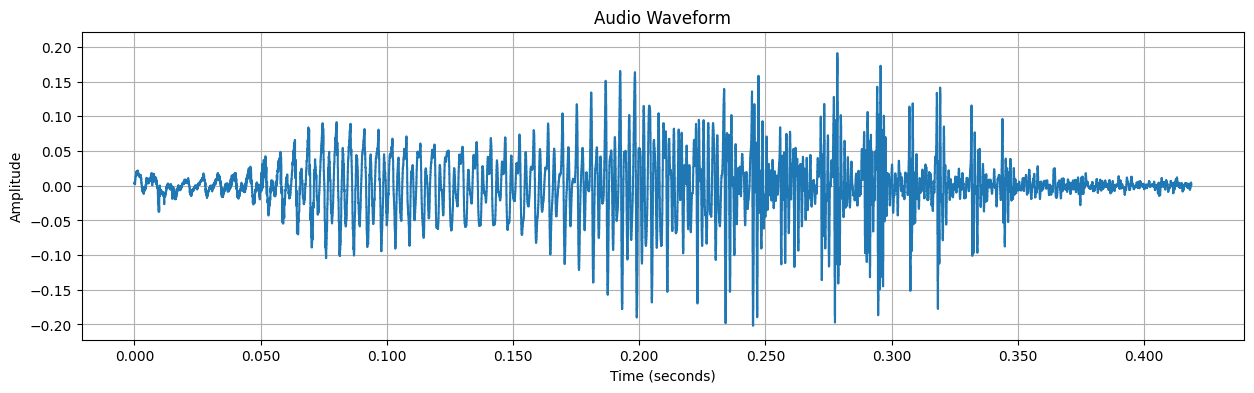

96076-100077


### Segment 11
- Start: **6.00 s**
- End: **6.25 s**
- Duration: **0.28 s**

Sample Rate: 16000
Duration: 0.28 seconds
Samples: 4401


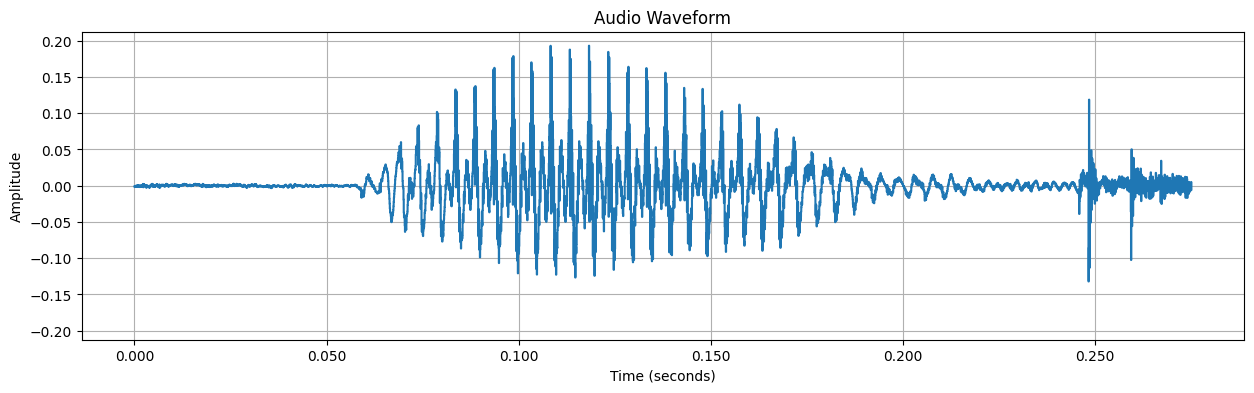

100077-106353


### Segment 11
- Start: **6.25 s**
- End: **6.65 s**
- Duration: **0.42 s**

Sample Rate: 16000
Duration: 0.42 seconds
Samples: 6676


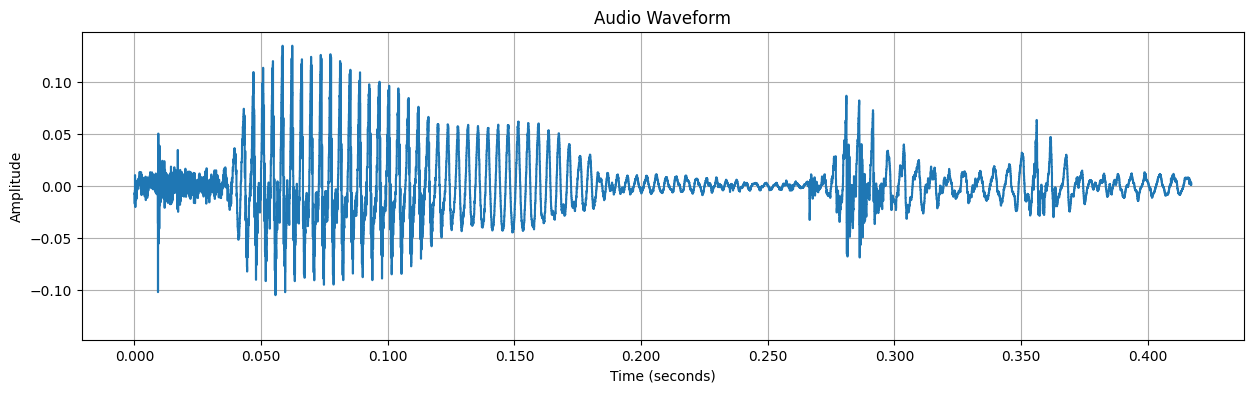

106353-111523


### Segment 11
- Start: **6.65 s**
- End: **6.97 s**
- Duration: **0.35 s**

Sample Rate: 16000
Duration: 0.35 seconds
Samples: 5570


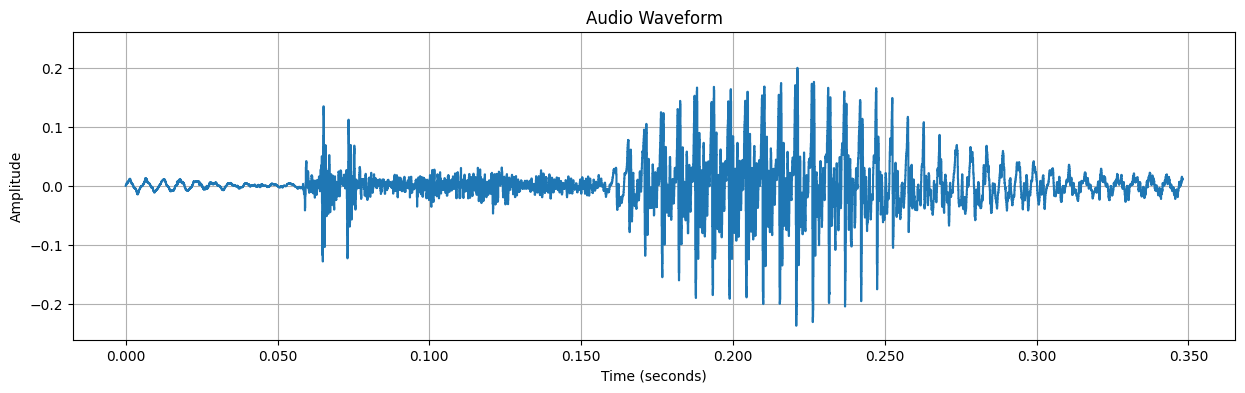

115524-119740


### Segment 11
- Start: **7.22 s**
- End: **7.48 s**
- Duration: **0.29 s**

Sample Rate: 16000
Duration: 0.29 seconds
Samples: 4616


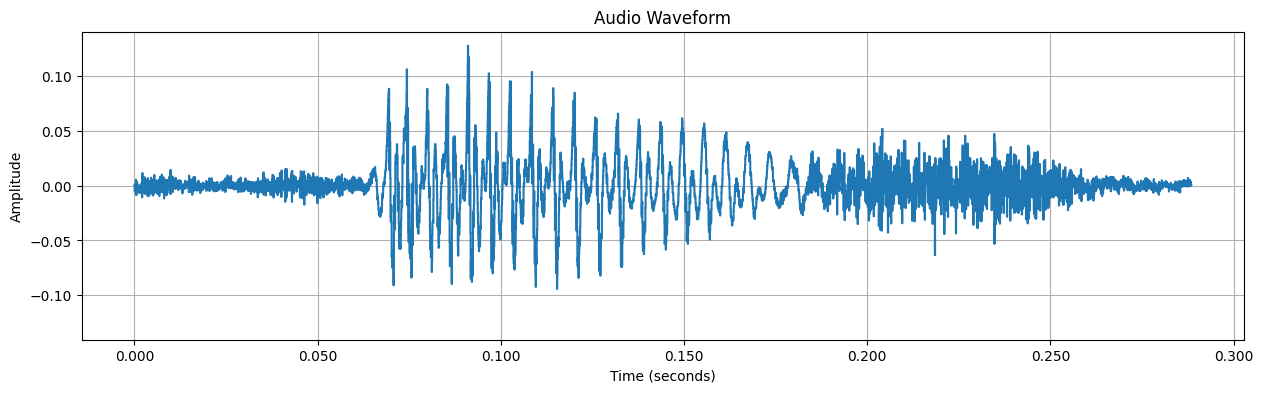

119740-123741


### Segment 11
- Start: **7.48 s**
- End: **7.73 s**
- Duration: **0.28 s**

Sample Rate: 16000
Duration: 0.28 seconds
Samples: 4401


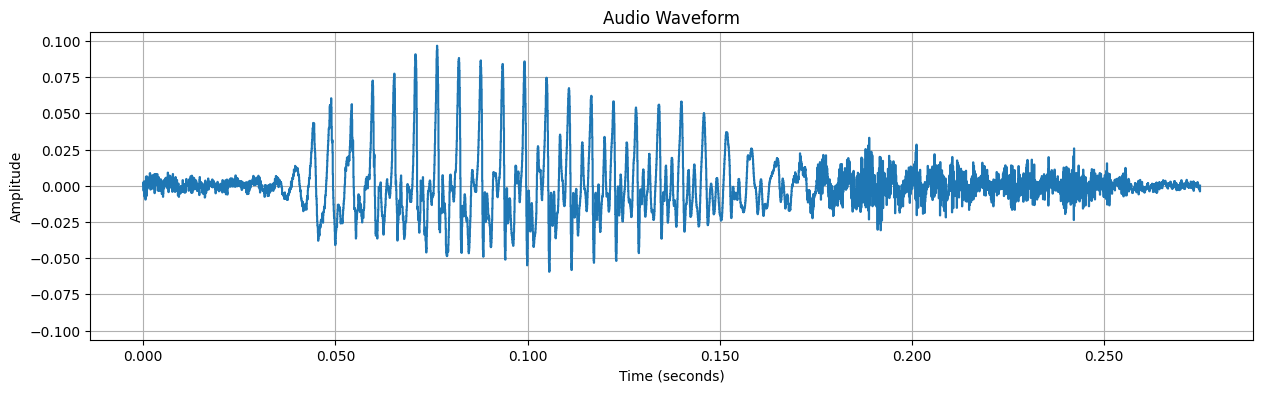

123741-128628


### Segment 11
- Start: **7.73 s**
- End: **8.04 s**
- Duration: **0.33 s**

Sample Rate: 16000
Duration: 0.33 seconds
Samples: 5287


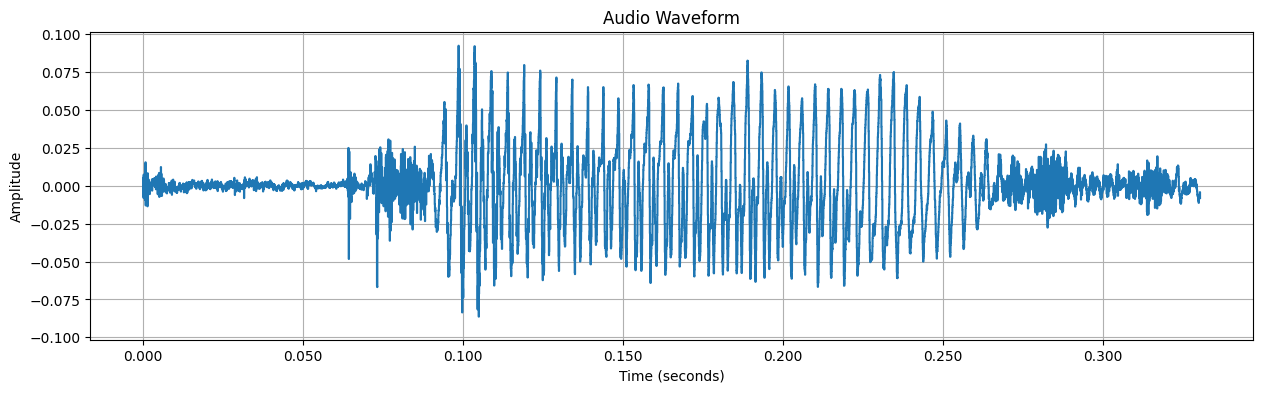

128628-132629


### Segment 11
- Start: **8.04 s**
- End: **8.29 s**
- Duration: **0.28 s**

Sample Rate: 16000
Duration: 0.28 seconds
Samples: 4401


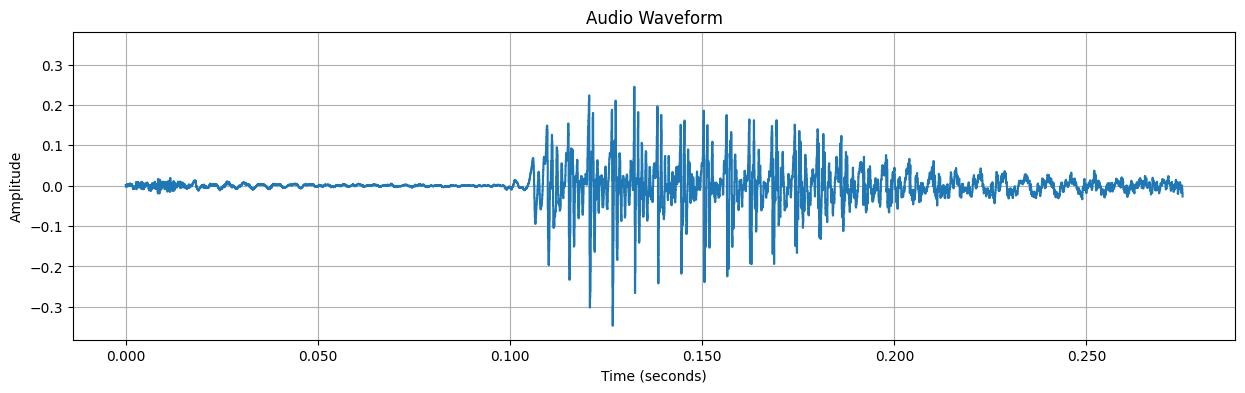

132629-136897


### Segment 11
- Start: **8.29 s**
- End: **8.56 s**
- Duration: **0.29 s**

Sample Rate: 16000
Duration: 0.29 seconds
Samples: 4668


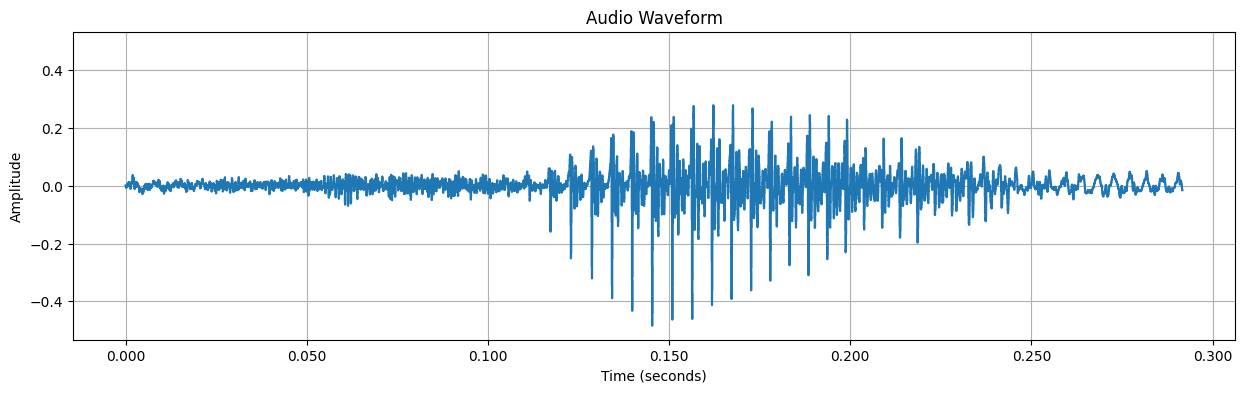

141546-145912


### Segment 11
- Start: **8.85 s**
- End: **9.12 s**
- Duration: **0.30 s**

Sample Rate: 16000
Duration: 0.30 seconds
Samples: 4766


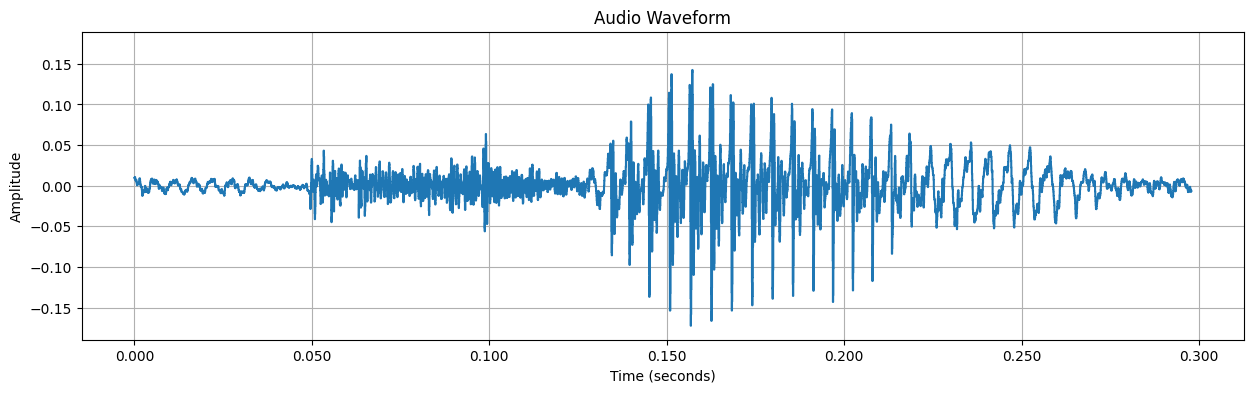

149913-157237


### Segment 11
- Start: **9.37 s**
- End: **9.83 s**
- Duration: **0.48 s**

Sample Rate: 16000
Duration: 0.48 seconds
Samples: 7724


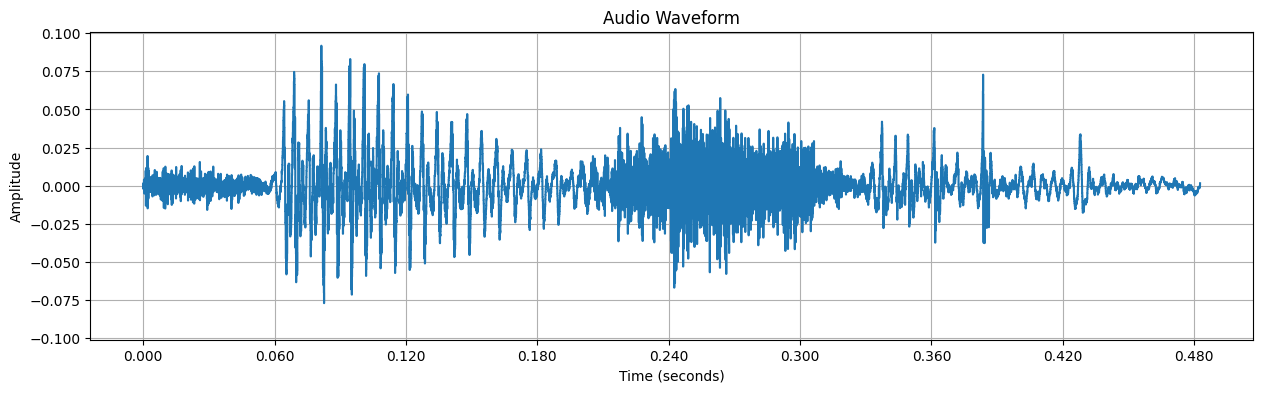

157237-162703


### Segment 11
- Start: **9.83 s**
- End: **10.17 s**
- Duration: **0.37 s**

Sample Rate: 16000
Duration: 0.37 seconds
Samples: 5866


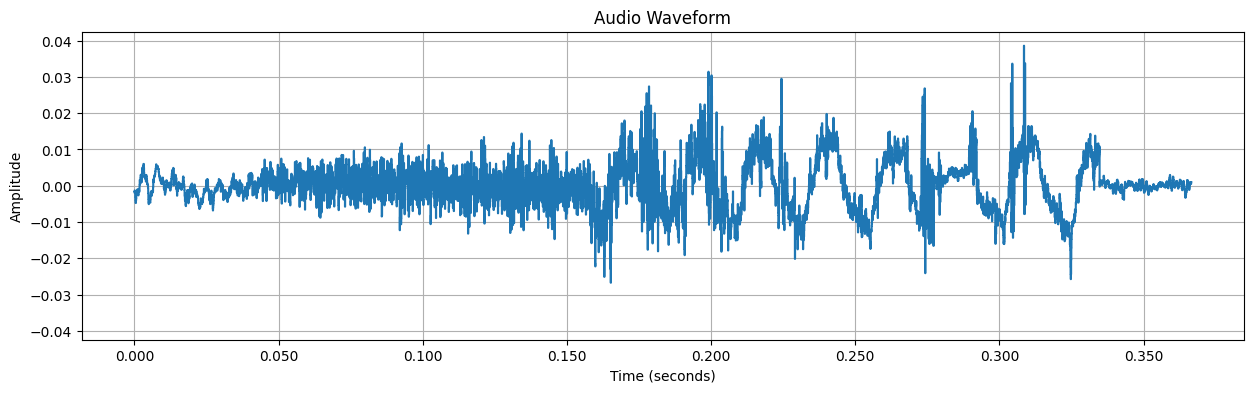

162703-170347


### Segment 11
- Start: **10.17 s**
- End: **10.65 s**
- Duration: **0.50 s**

Sample Rate: 16000
Duration: 0.50 seconds
Samples: 8044


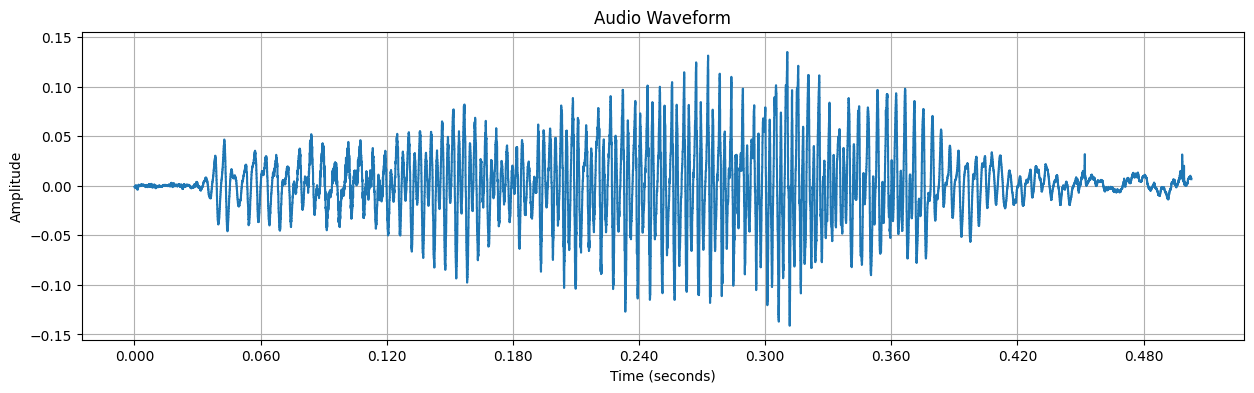

170347-175732


### Segment 11
- Start: **10.65 s**
- End: **10.98 s**
- Duration: **0.36 s**

Sample Rate: 16000
Duration: 0.36 seconds
Samples: 5785


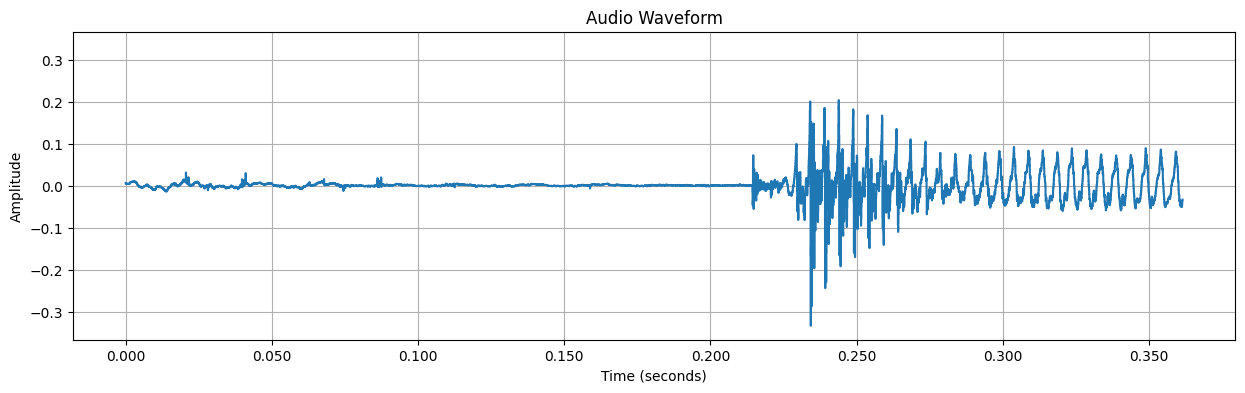

180374-186254


### Segment 11
- Start: **11.27 s**
- End: **11.64 s**
- Duration: **0.39 s**

Sample Rate: 16000
Duration: 0.39 seconds
Samples: 6280


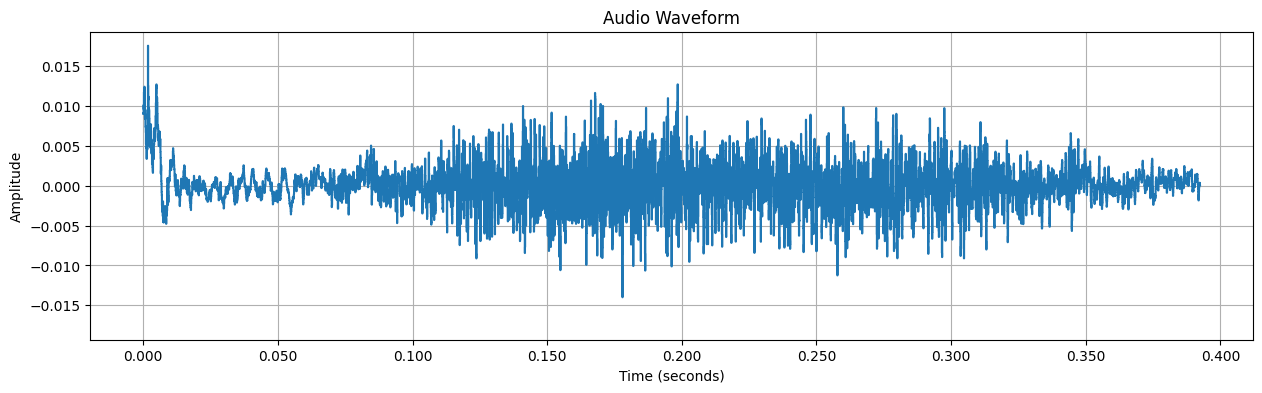

190255-195628


### Segment 11
- Start: **11.89 s**
- End: **12.23 s**
- Duration: **0.36 s**

Sample Rate: 16000
Duration: 0.36 seconds
Samples: 5773


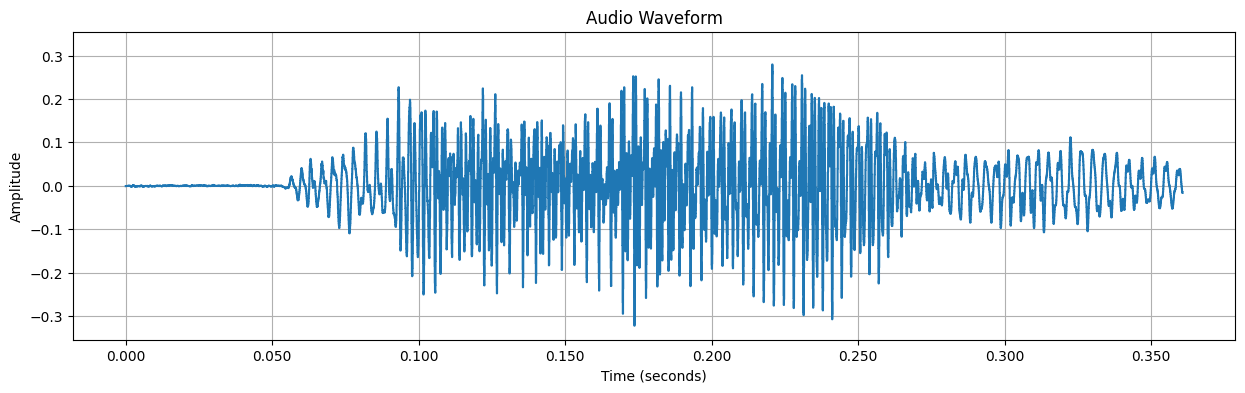

195628-203660


### Segment 11
- Start: **12.23 s**
- End: **12.73 s**
- Duration: **0.53 s**

Sample Rate: 16000
Duration: 0.53 seconds
Samples: 8432


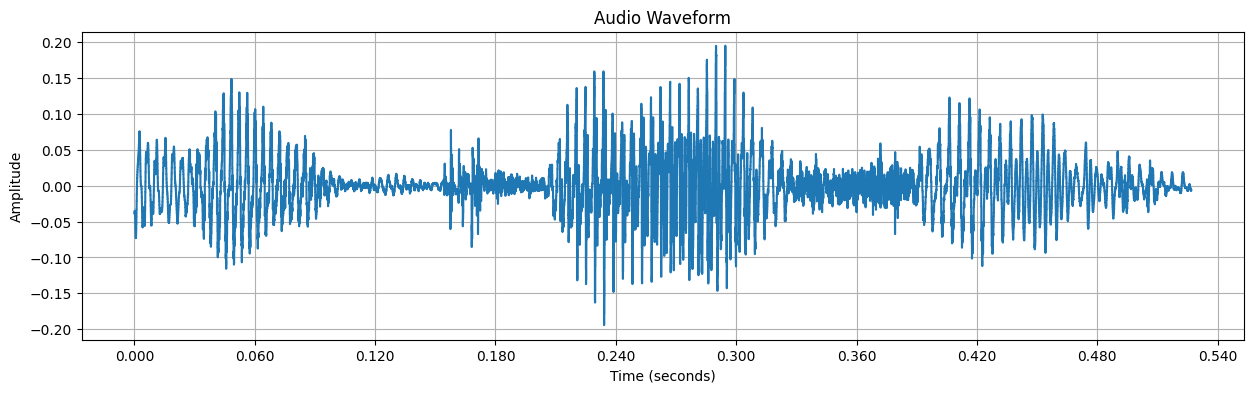

203660-209592


### Segment 11
- Start: **12.73 s**
- End: **13.10 s**
- Duration: **0.40 s**

Sample Rate: 16000
Duration: 0.40 seconds
Samples: 6332


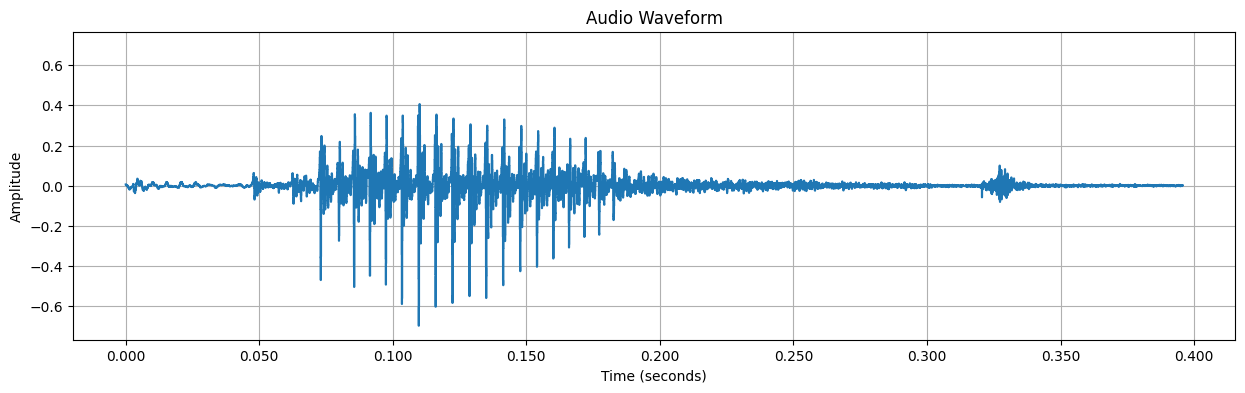

209592-215793


### Segment 11
- Start: **13.10 s**
- End: **13.49 s**
- Duration: **0.41 s**

Sample Rate: 16000
Duration: 0.41 seconds
Samples: 6601


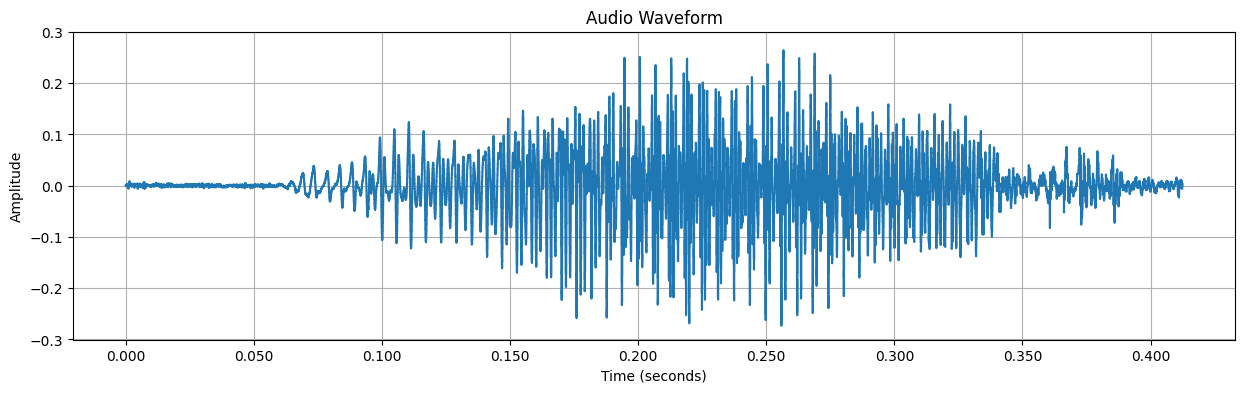

215793-223155


### Segment 11
- Start: **13.49 s**
- End: **13.95 s**
- Duration: **0.49 s**

Sample Rate: 16000
Duration: 0.49 seconds
Samples: 7762


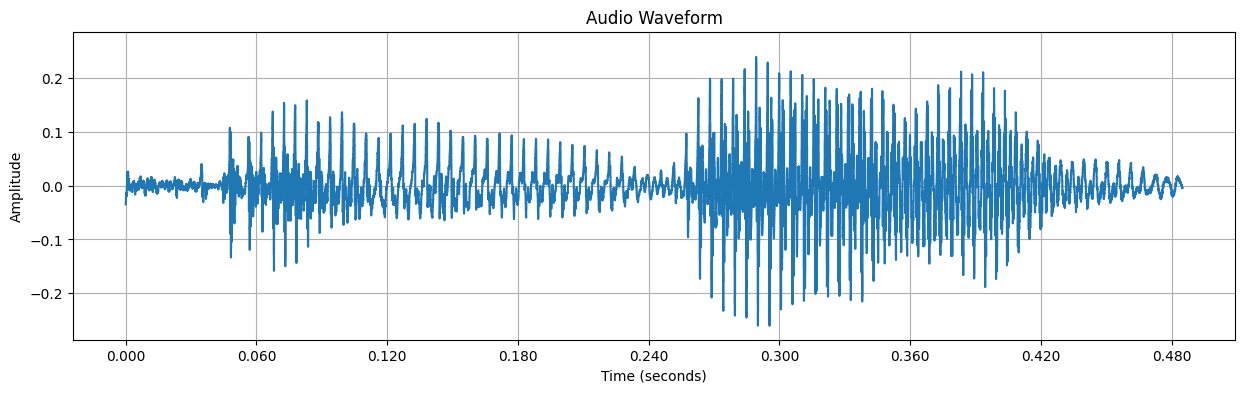

223155-228160


### Segment 11
- Start: **13.95 s**
- End: **14.26 s**
- Duration: **0.34 s**

Sample Rate: 16000
Duration: 0.34 seconds
Samples: 5405


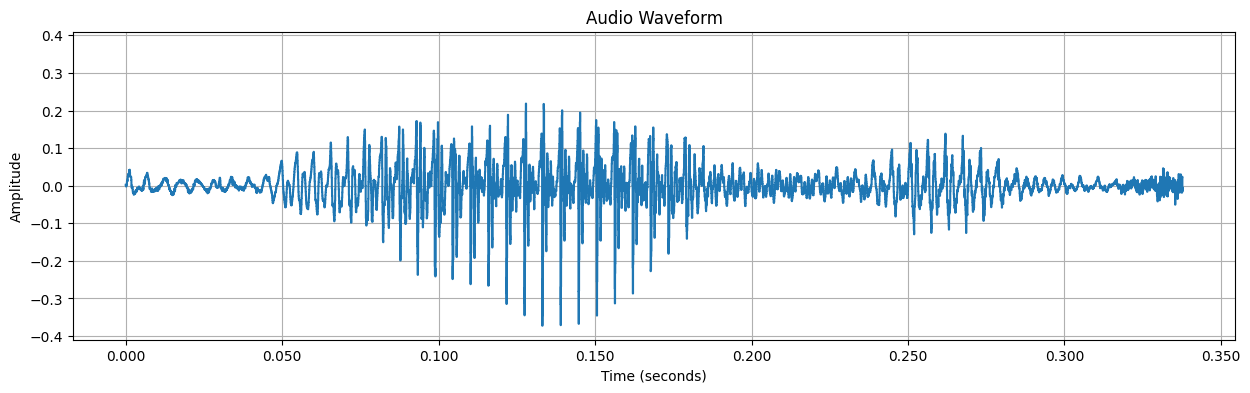

228160-234211


### Segment 11
- Start: **14.26 s**
- End: **14.64 s**
- Duration: **0.40 s**

Sample Rate: 16000
Duration: 0.40 seconds
Samples: 6451


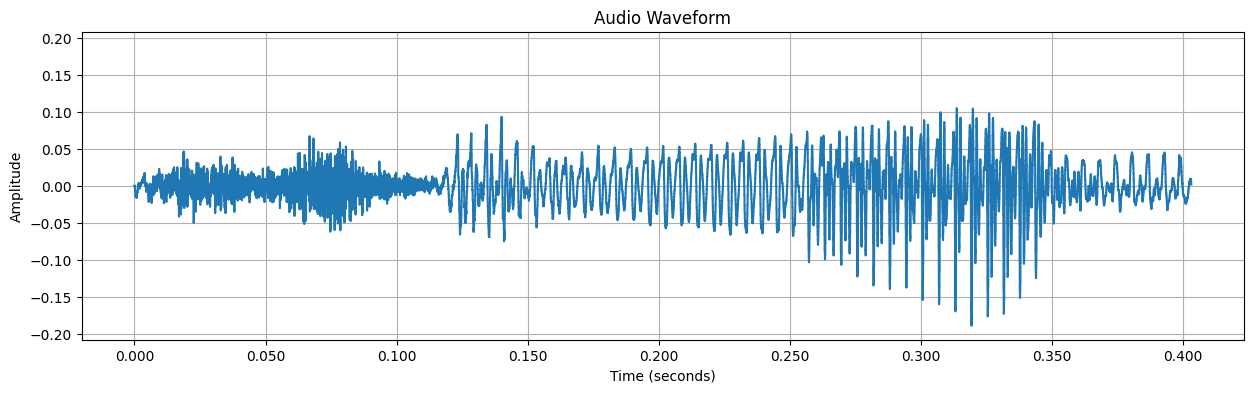

238212-243999


### Segment 11
- Start: **14.89 s**
- End: **15.25 s**
- Duration: **0.37 s**

Sample Rate: 16000
Duration: 0.37 seconds
Samples: 5988


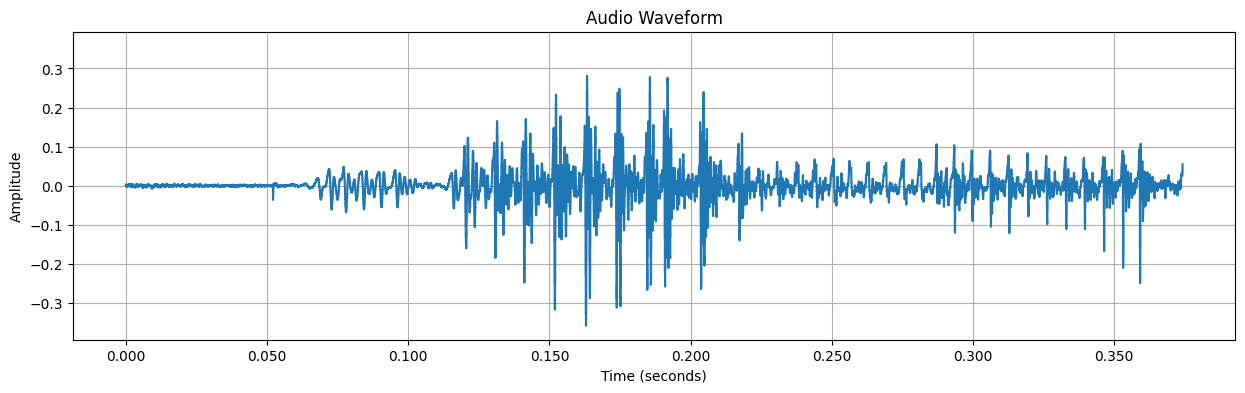

In [136]:
#show them to play on colab
import librosa
import numpy as np
from IPython.display import Audio, display, Markdown

padding = 200 #40 for birds 200 for humans
print(f"Detected {len(breaks)} candidate segments\n")
for (st, en) in intervals:
  print(str(st)+"-"+str(en))
  segment = audio[st-padding:en+padding]
  duration = len(segment) / sr

  display(Markdown(
      f"### Segment {i+1}\n"
      f"- Start: **{st/sr:.2f} s**\n"
      f"- End: **{en/sr:.2f} s**\n"
      f"- Duration: **{duration:.2f} s**"
  ))

  display(Audio(segment, rate=sr))
  show_audio(segment, sr)


# for i, end_frame in enumerate(breaks):
#     end = end_frame * hop

#     # Skip segments shorter than 150 ms
#     if end - start < int(sr * 0.15):
#         continue

#     segment = y[start:end]

#     duration = len(segment) / sr

#     display(Markdown(
#         f"### Segment {i+1}\n"
#         f"- Start: **{start/sr:.2f} s**\n"
#         f"- End: **{end/sr:.2f} s**\n"
#         f"- Duration: **{duration:.2f} s**"
#     ))

#     display(Audio(segment, rate=sr))

#     start = end

# gjdhf X
this is not used

In [ ]:
import numpy as np
from scipy.signal import find_peaks

def find_word_boundaries(envelope,
                         min_peak_height=None,
                         min_peak_distance=100,
                         prominence=None):
    """
    Find candidate word boundaries from an energy envelope.

    Parameters
    ----------
    envelope : np.ndarray
        Gaussian RMS envelope.
    min_peak_height : float or None
        Minimum peak height. If None, computed automatically.
    min_peak_distance : int
        Minimum distance between peaks (samples).
    prominence : float or None
        Peak prominence.

    Returns
    -------
    peaks : np.ndarray
        Peak indices.
    boundaries : np.ndarray
        Local minima between peaks.
    """

    envelope = np.asarray(envelope)

    if min_peak_height is None:
        min_peak_height = envelope.mean()

    peaks, _ = find_peaks(
        envelope,
        height=min_peak_height,
        distance=min_peak_distance,
        prominence=prominence
    )

    boundaries = []

    for i in range(len(peaks) - 1):
        left = peaks[i]
        right = peaks[i + 1]

        valley = left + np.argmin(envelope[left:right + 1])
        boundaries.append(valley)

    return peaks, np.array(boundaries)

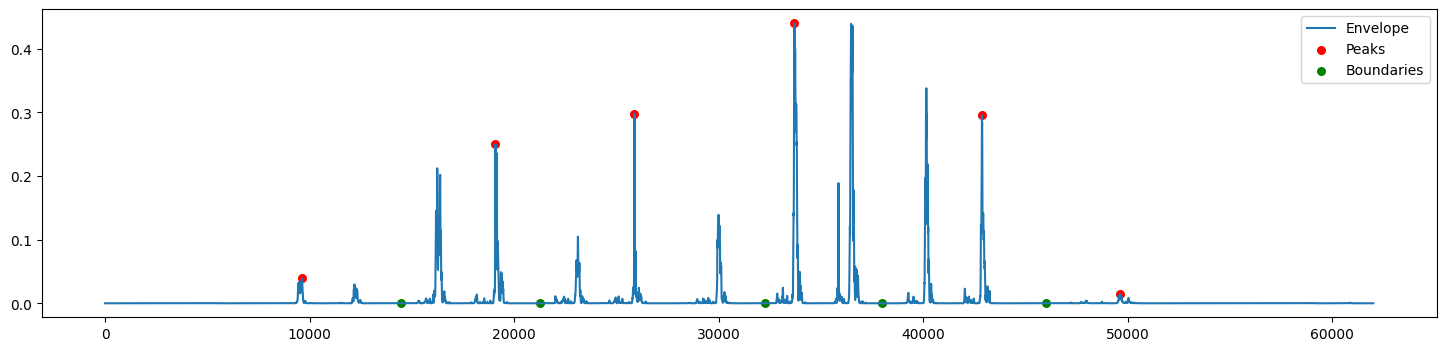

In [ ]:
import matplotlib.pyplot as plt

env = gl_energy #gaussian_rms_envelope(audio, sigma=80)

peaks, boundaries = find_word_boundaries(
    env,
    min_peak_distance=int(0.15 * sr)   # 150 ms
)

plt.figure(figsize=(18,4))
plt.plot(env, label="Envelope")

plt.scatter(peaks,
            env[peaks],
            color="red",
            s=30,
            label="Peaks")

plt.scatter(boundaries,
            env[boundaries],
            color="green",
            s=30,
            label="Boundaries")

plt.legend()
plt.show()